In [1]:
import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pymc as pm
import arviz as az
from scipy.special import expit

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set(rc={"figure.figsize" : (25, 15)})
sns.set(font_scale=2)
sns.set_style("ticks")

In [2]:
df = pandas.read_csv(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=csv",
    parse_dates=["end_date"])
df = df[df["pollster"].notnull()].copy()
del df["url"]

In [3]:
df["partisan"].value_counts()

partisan
Sherrill    8
0           4
Baraka      4
Spiller     4
Fulop       3
Name: count, dtype: int64

In [4]:
df = df.melt(
    id_vars=["pollster", "end_date", "population", "mode", "sample_size", "moe", "kind", "partisan", "Weight"],
    var_name="candidate", value_name="pct")

In [5]:
df["pct_lower"] = df["pct"] - df["moe"]
df["pct_upper"] = df["pct"] + df["moe"]
df["pct_lower"] = df["pct_lower"].apply(lambda x : 0 if x < 0 else x)

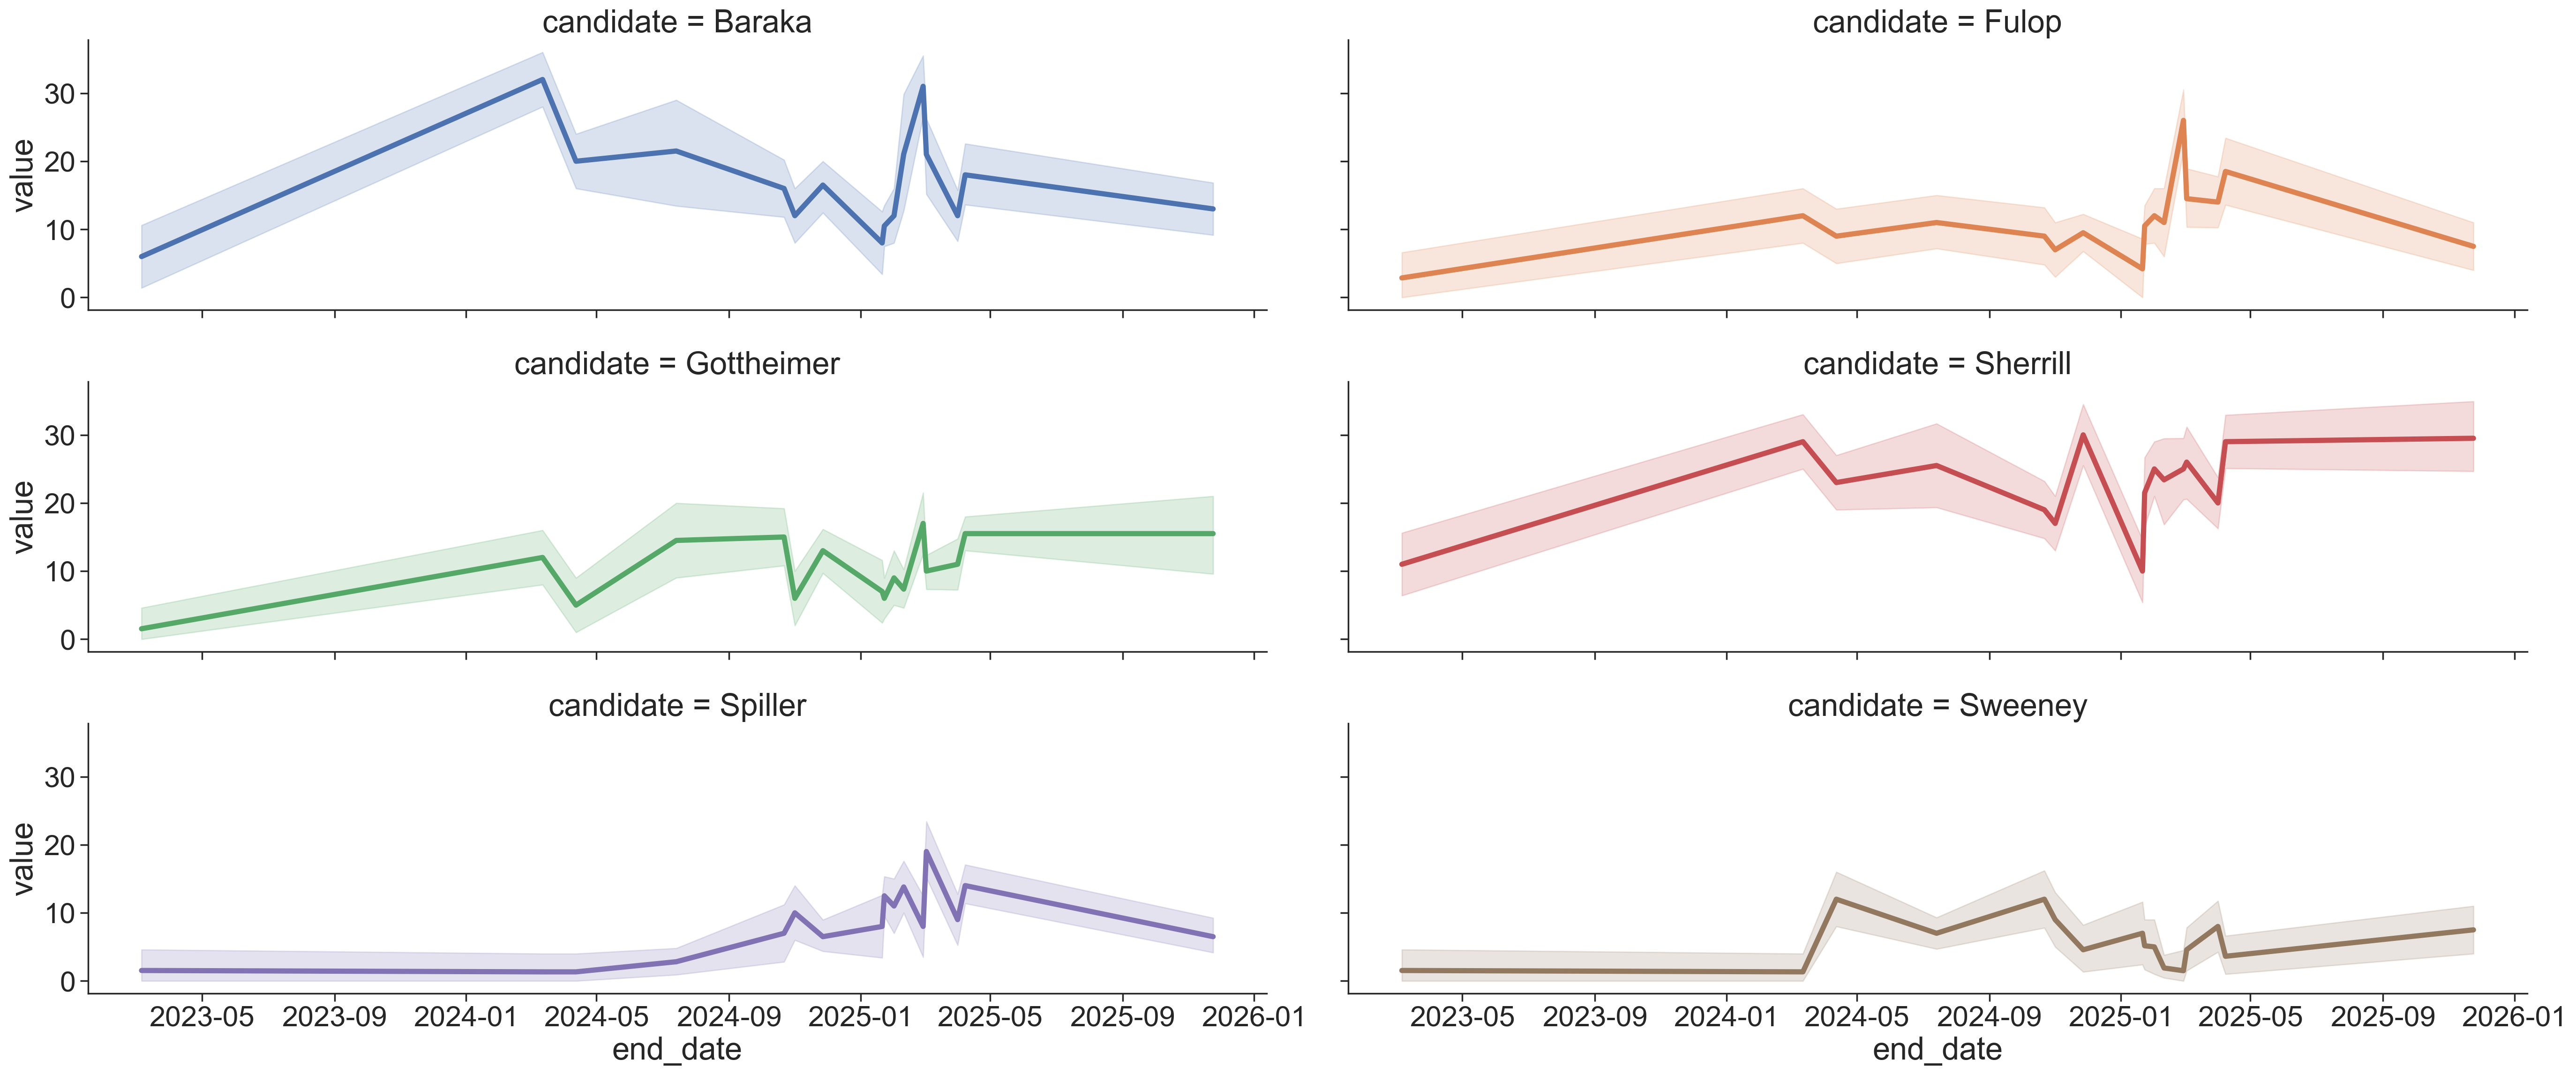

In [6]:
for_plot = df[["end_date", "candidate", "partisan", "pct", "pct_lower", "pct_upper"]].copy()
for_plot = for_plot.melt(id_vars=["end_date", "candidate", "partisan"])

ax = sns.relplot(data=for_plot[for_plot["candidate"] != "Undecided"], x="end_date", y="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="line", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

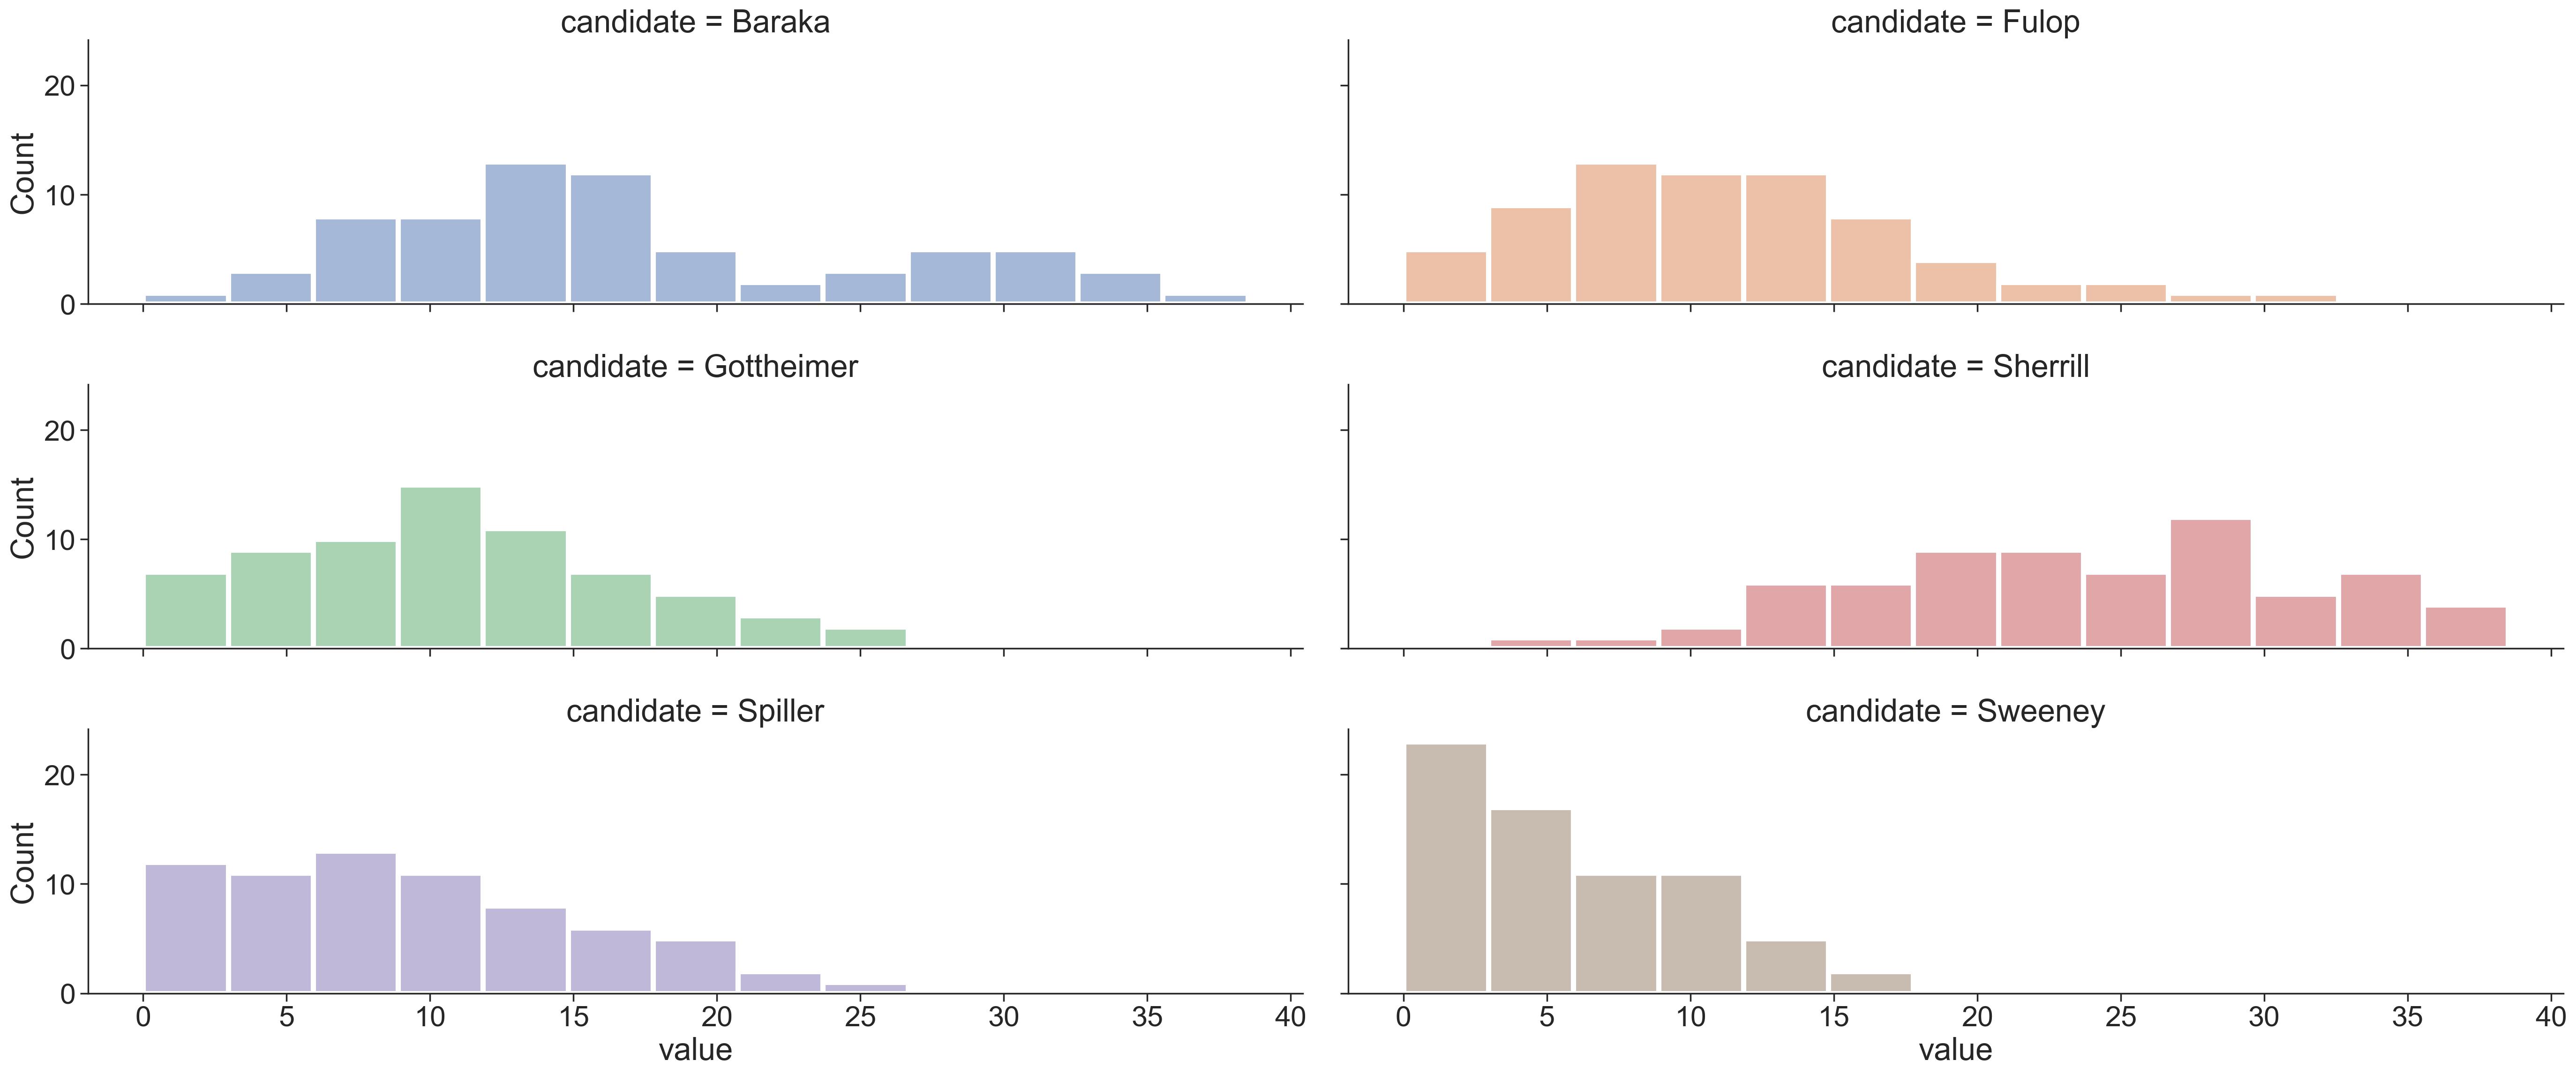

In [7]:
ax = sns.displot(data=for_plot[for_plot["candidate"] != "Undecided"], x="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="hist", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

In [8]:
(for_plot.groupby(["candidate", "partisan"]).agg({"value" : "mean"}).reset_index()
 .pivot(index="candidate", columns="partisan", values="value"))

partisan,0,Baraka,Fulop,Sherrill,Spiller
candidate,,,,,
Baraka,15.250000,21.275000,12.000000,18.375000,15.750000
Fulop,10.516667,11.000000,11.000000,11.500000,12.500000
Gottheimer,10.133333,10.925000,8.666667,13.125000,8.000000
Sherrill,16.250000,24.450000,20.666667,28.625000,23.750000
Spiller,6.133333,8.310000,10.000000,7.083333,15.750000
Sweeney,5.508333,4.450000,7.333333,5.591250,4.875000
Undecided,40.125000,27.313333,30.333333,18.176250,23.541667


In [9]:
df["num_for"] = ((df["pct"] / 100) * df["sample_size"]).round(0)
df["num_for_lower"] = ((df["pct_lower"] / 100) * df["sample_size"]).round(0)
df["num_for_upper"] = ((df["pct_upper"] / 100) * df["sample_size"]).round(0)

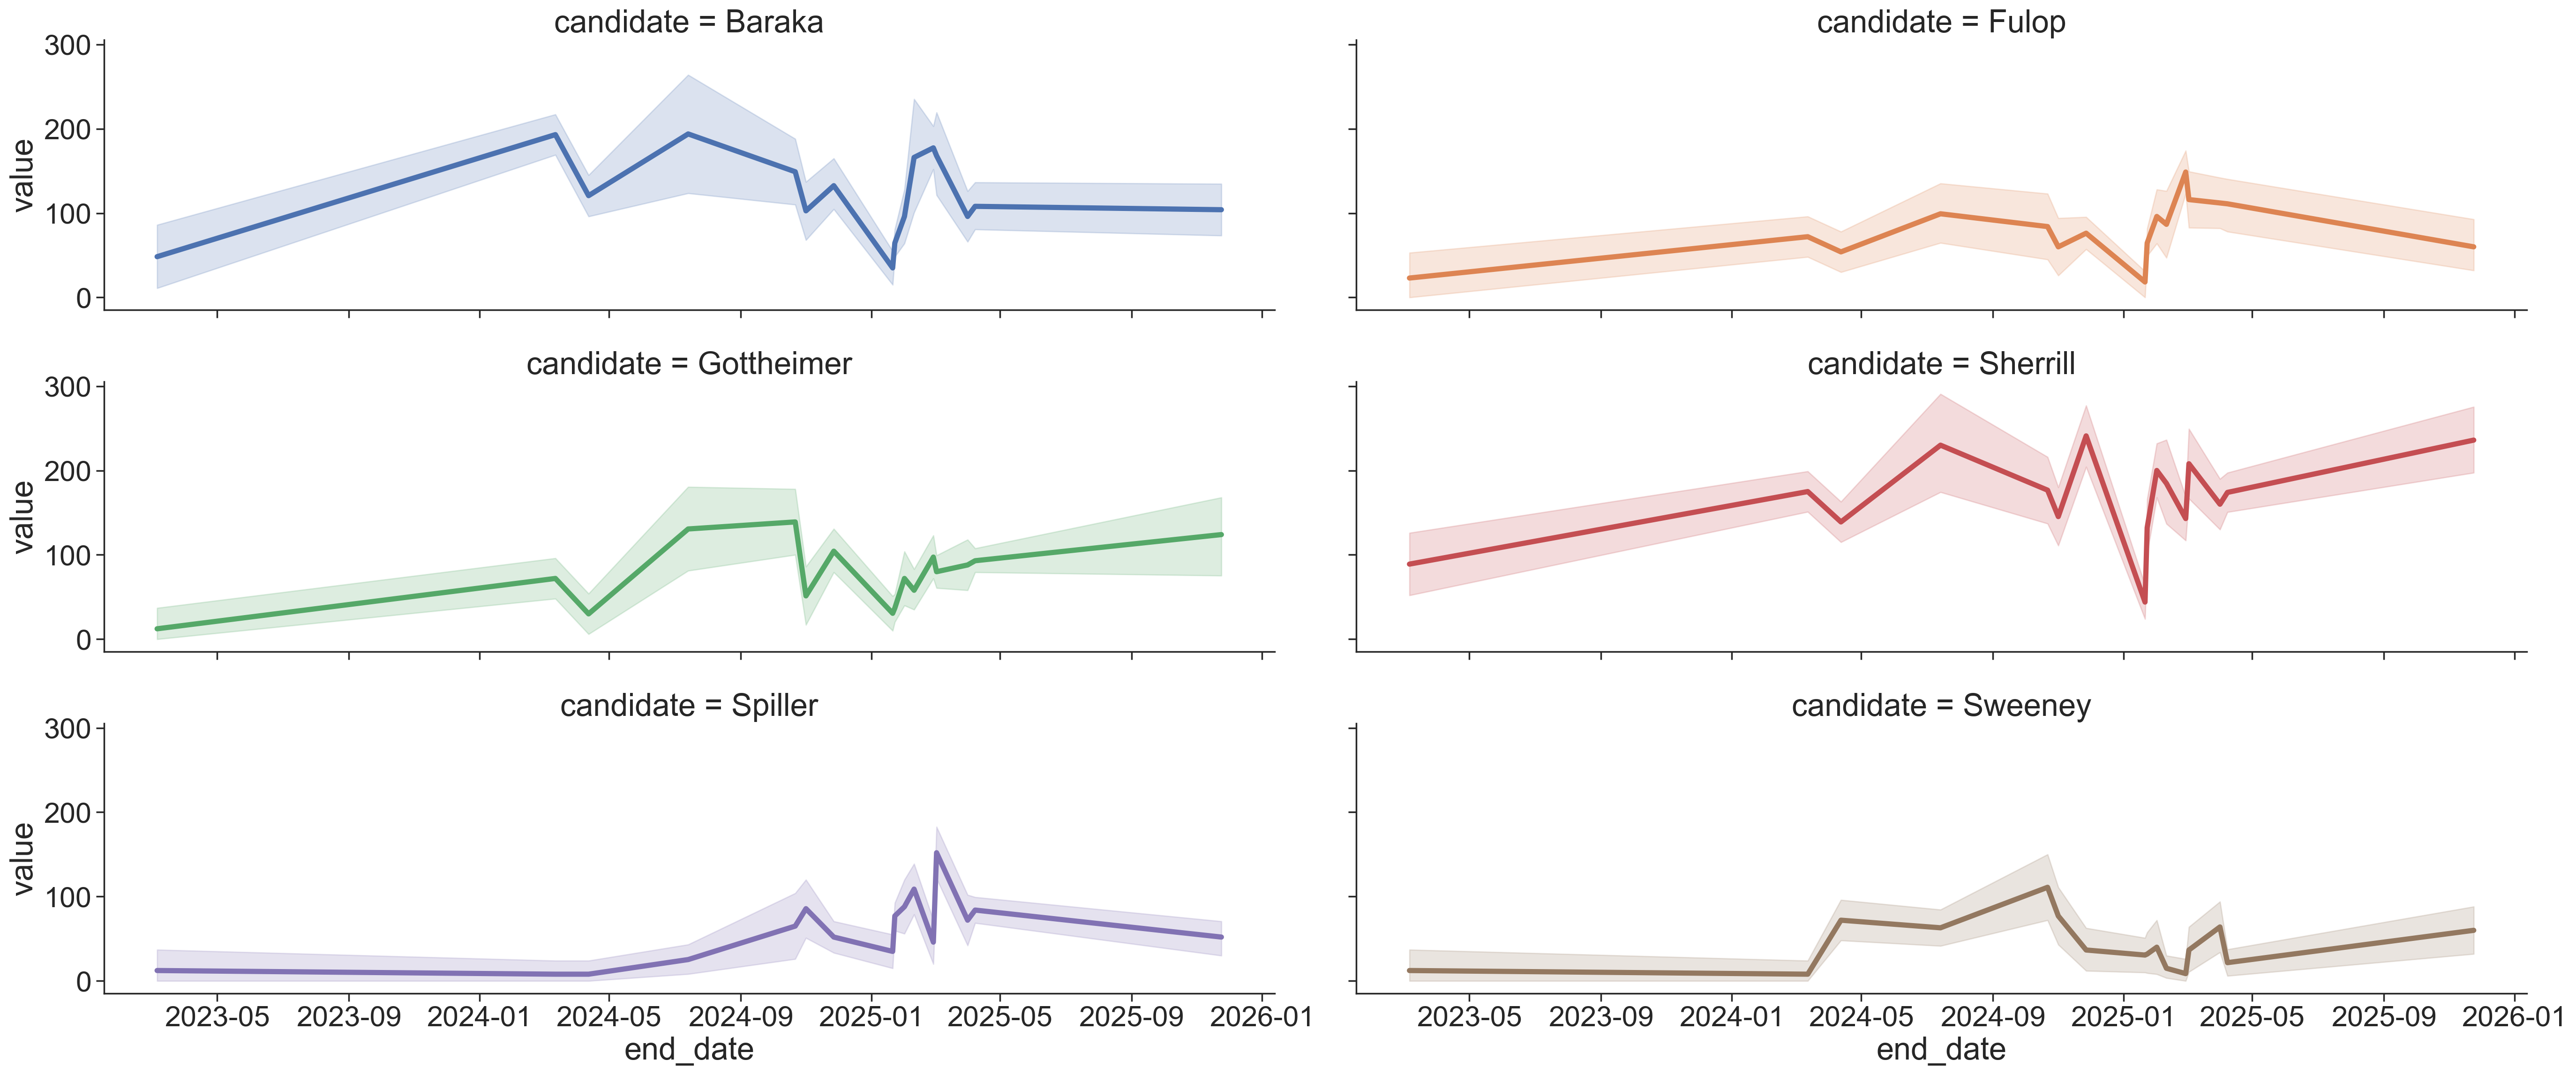

In [10]:
for_plot = df[["end_date", "candidate", "num_for", "num_for_lower", "num_for_upper"]].copy()
for_plot = for_plot.melt(id_vars=["end_date", "candidate"])

ax = sns.relplot(data=for_plot[for_plot["candidate"] != "Undecided"], x="end_date", y="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="line", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

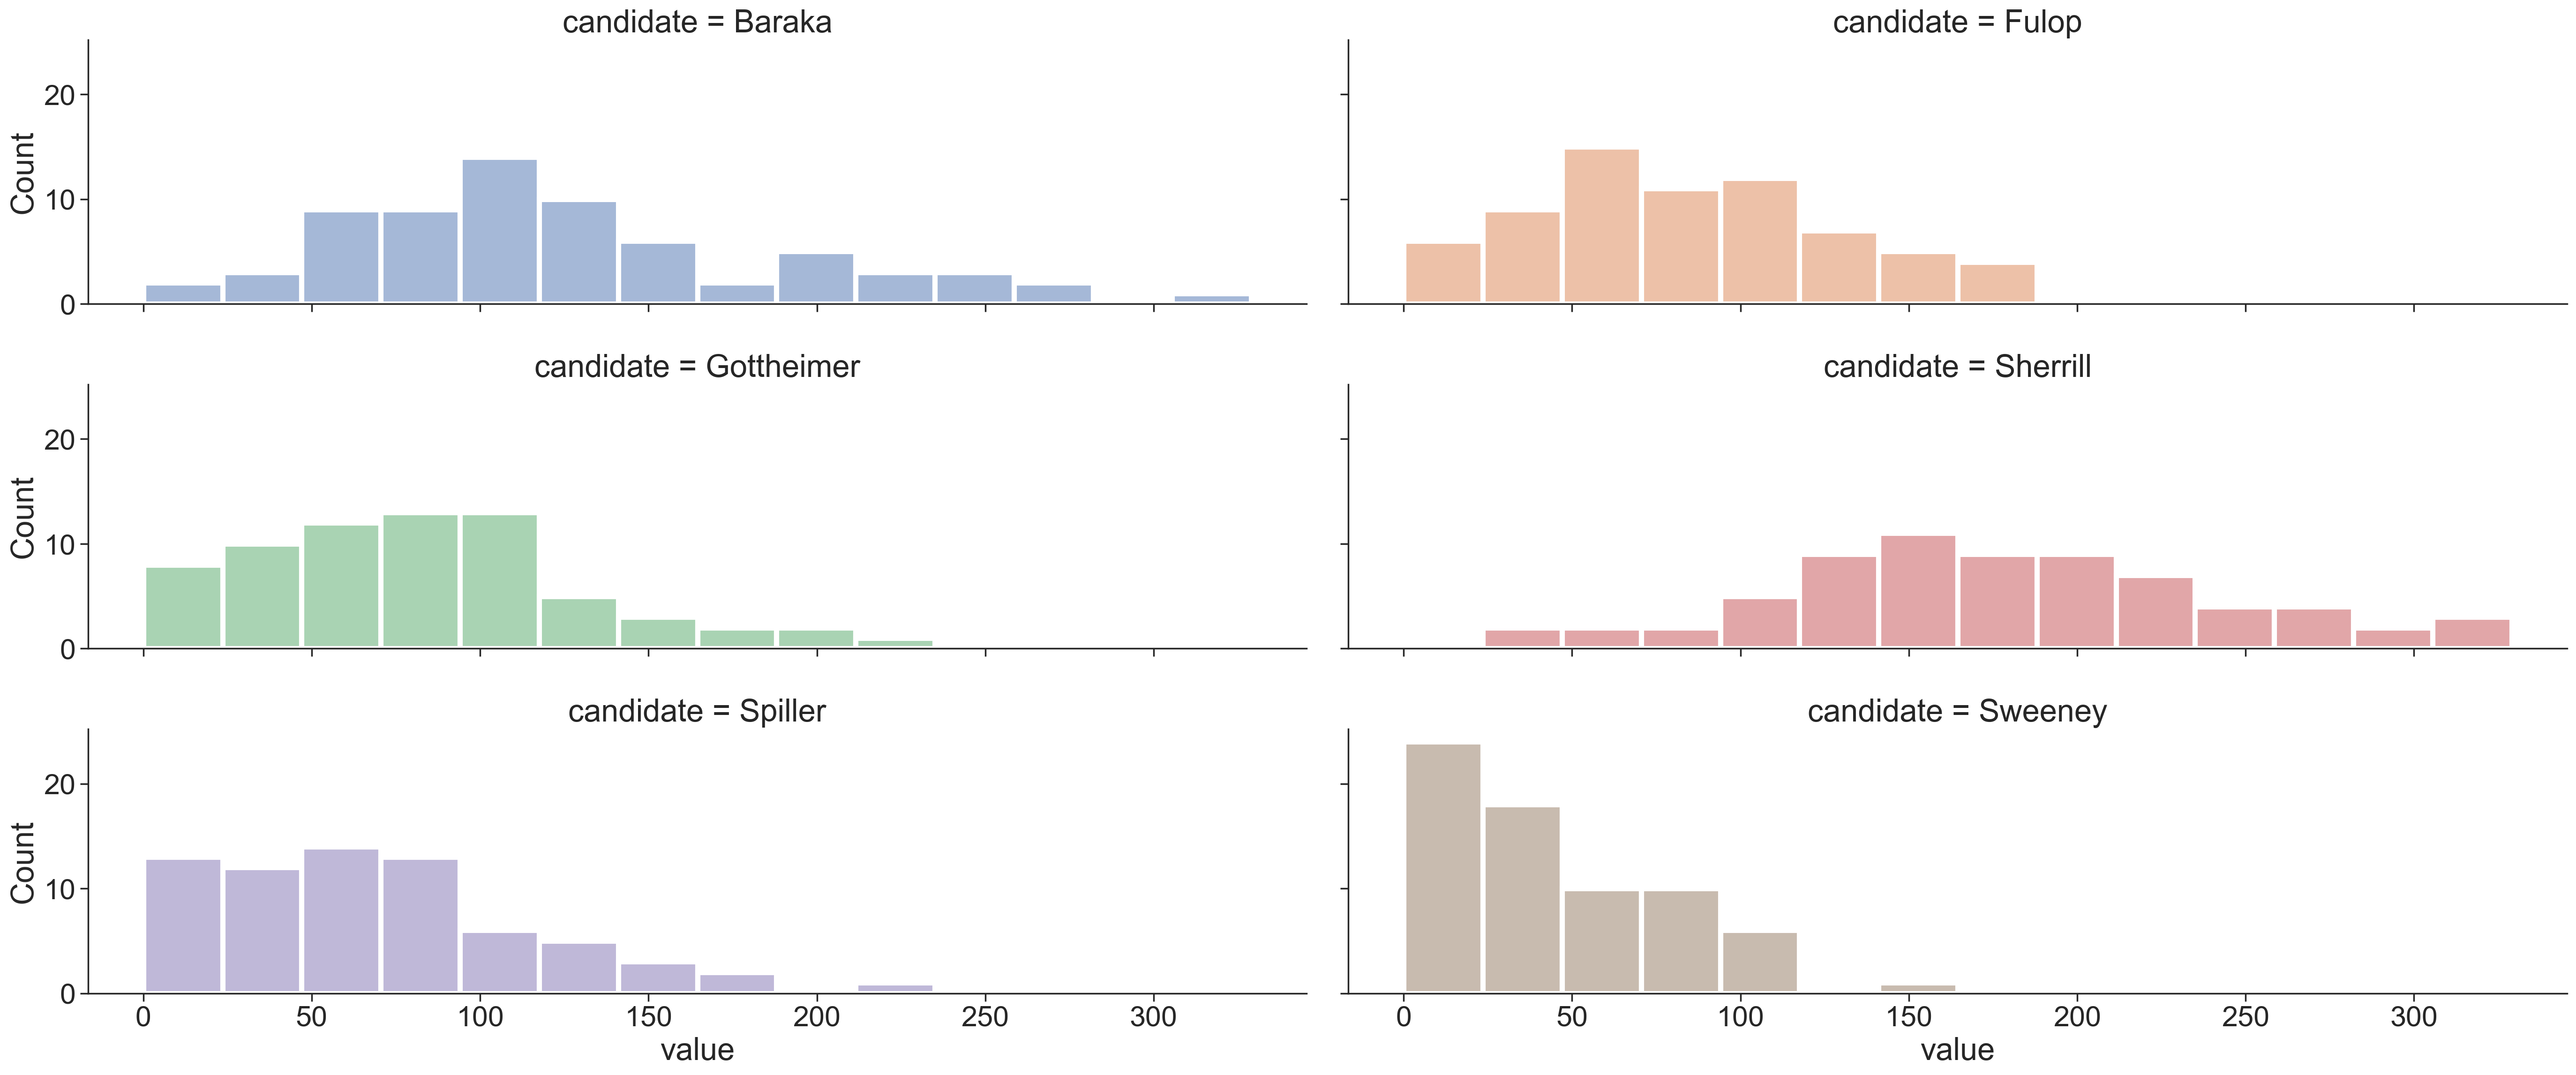

In [11]:
ax = sns.displot(data=for_plot[for_plot["candidate"] != "Undecided"], x="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="hist", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

---

In [12]:
# based on https://alexandorra.github.io/pollsposition_blog/popularity/macron/hidden%20markov%20models/polls/2021/05/16/hmm-popularity.html

In [13]:
df = df.melt(id_vars=[c for c in df.columns if not c.startswith("num_for")])
df = df.rename(columns={"value" : "num_for"})

# Non-Partisan Polls Only

In [14]:
np_df = df[df["partisan"] == "0"].copy()

In [15]:
# TODO: consider days from the election and not as a fixed effect

month_id, months = np_df["end_date"].dt.to_period("M").factorize(sort=False)
months = [str(m) for m in months]

In [16]:
cand_id, candidates = np_df["candidate"].factorize(sort=False)

In [17]:
np_df["mode_pop"] = np_df.apply(lambda x : " / ".join([x["mode"], x["population"]]), axis=1)
mode_pop_id, mode_pop = np_df["mode_pop"].factorize(sort=False)

In [18]:
coords = {
    "observation" : np_df.index,
    "candidate" : candidates,
    "month" : months,
    "mode_pop" : mode_pop
}

In [19]:
with pm.Model(coords=coords) as model:
    month_effect = pm.Normal("month_effect", 0, 0.15, dims="month")
    mode_pop_effect = pm.Normal("mode_pop_effect", 0, 0.15, dims="mode_pop")
    shrinkage_pop = pm.HalfNormal("shrinkage_pop", 0.2)
    cand_effect = pm.Normal("candidate_effect", mu=0, sigma=shrinkage_pop, dims="candidate")

    popularity = pm.math.invlogit(month_effect[month_id] + mode_pop_effect[mode_pop_id] + cand_effect[cand_id])

    y_hat = pm.Binomial(
        "y_hat",
        p=popularity,
        n=np_df["sample_size"],
        observed=np_df["num_for"],
        dims="observation",
    )

In [20]:
with model:
    idata = pm.sample(extend_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [month_effect, mode_pop_effect, shrinkage_pop, candidate_effect]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


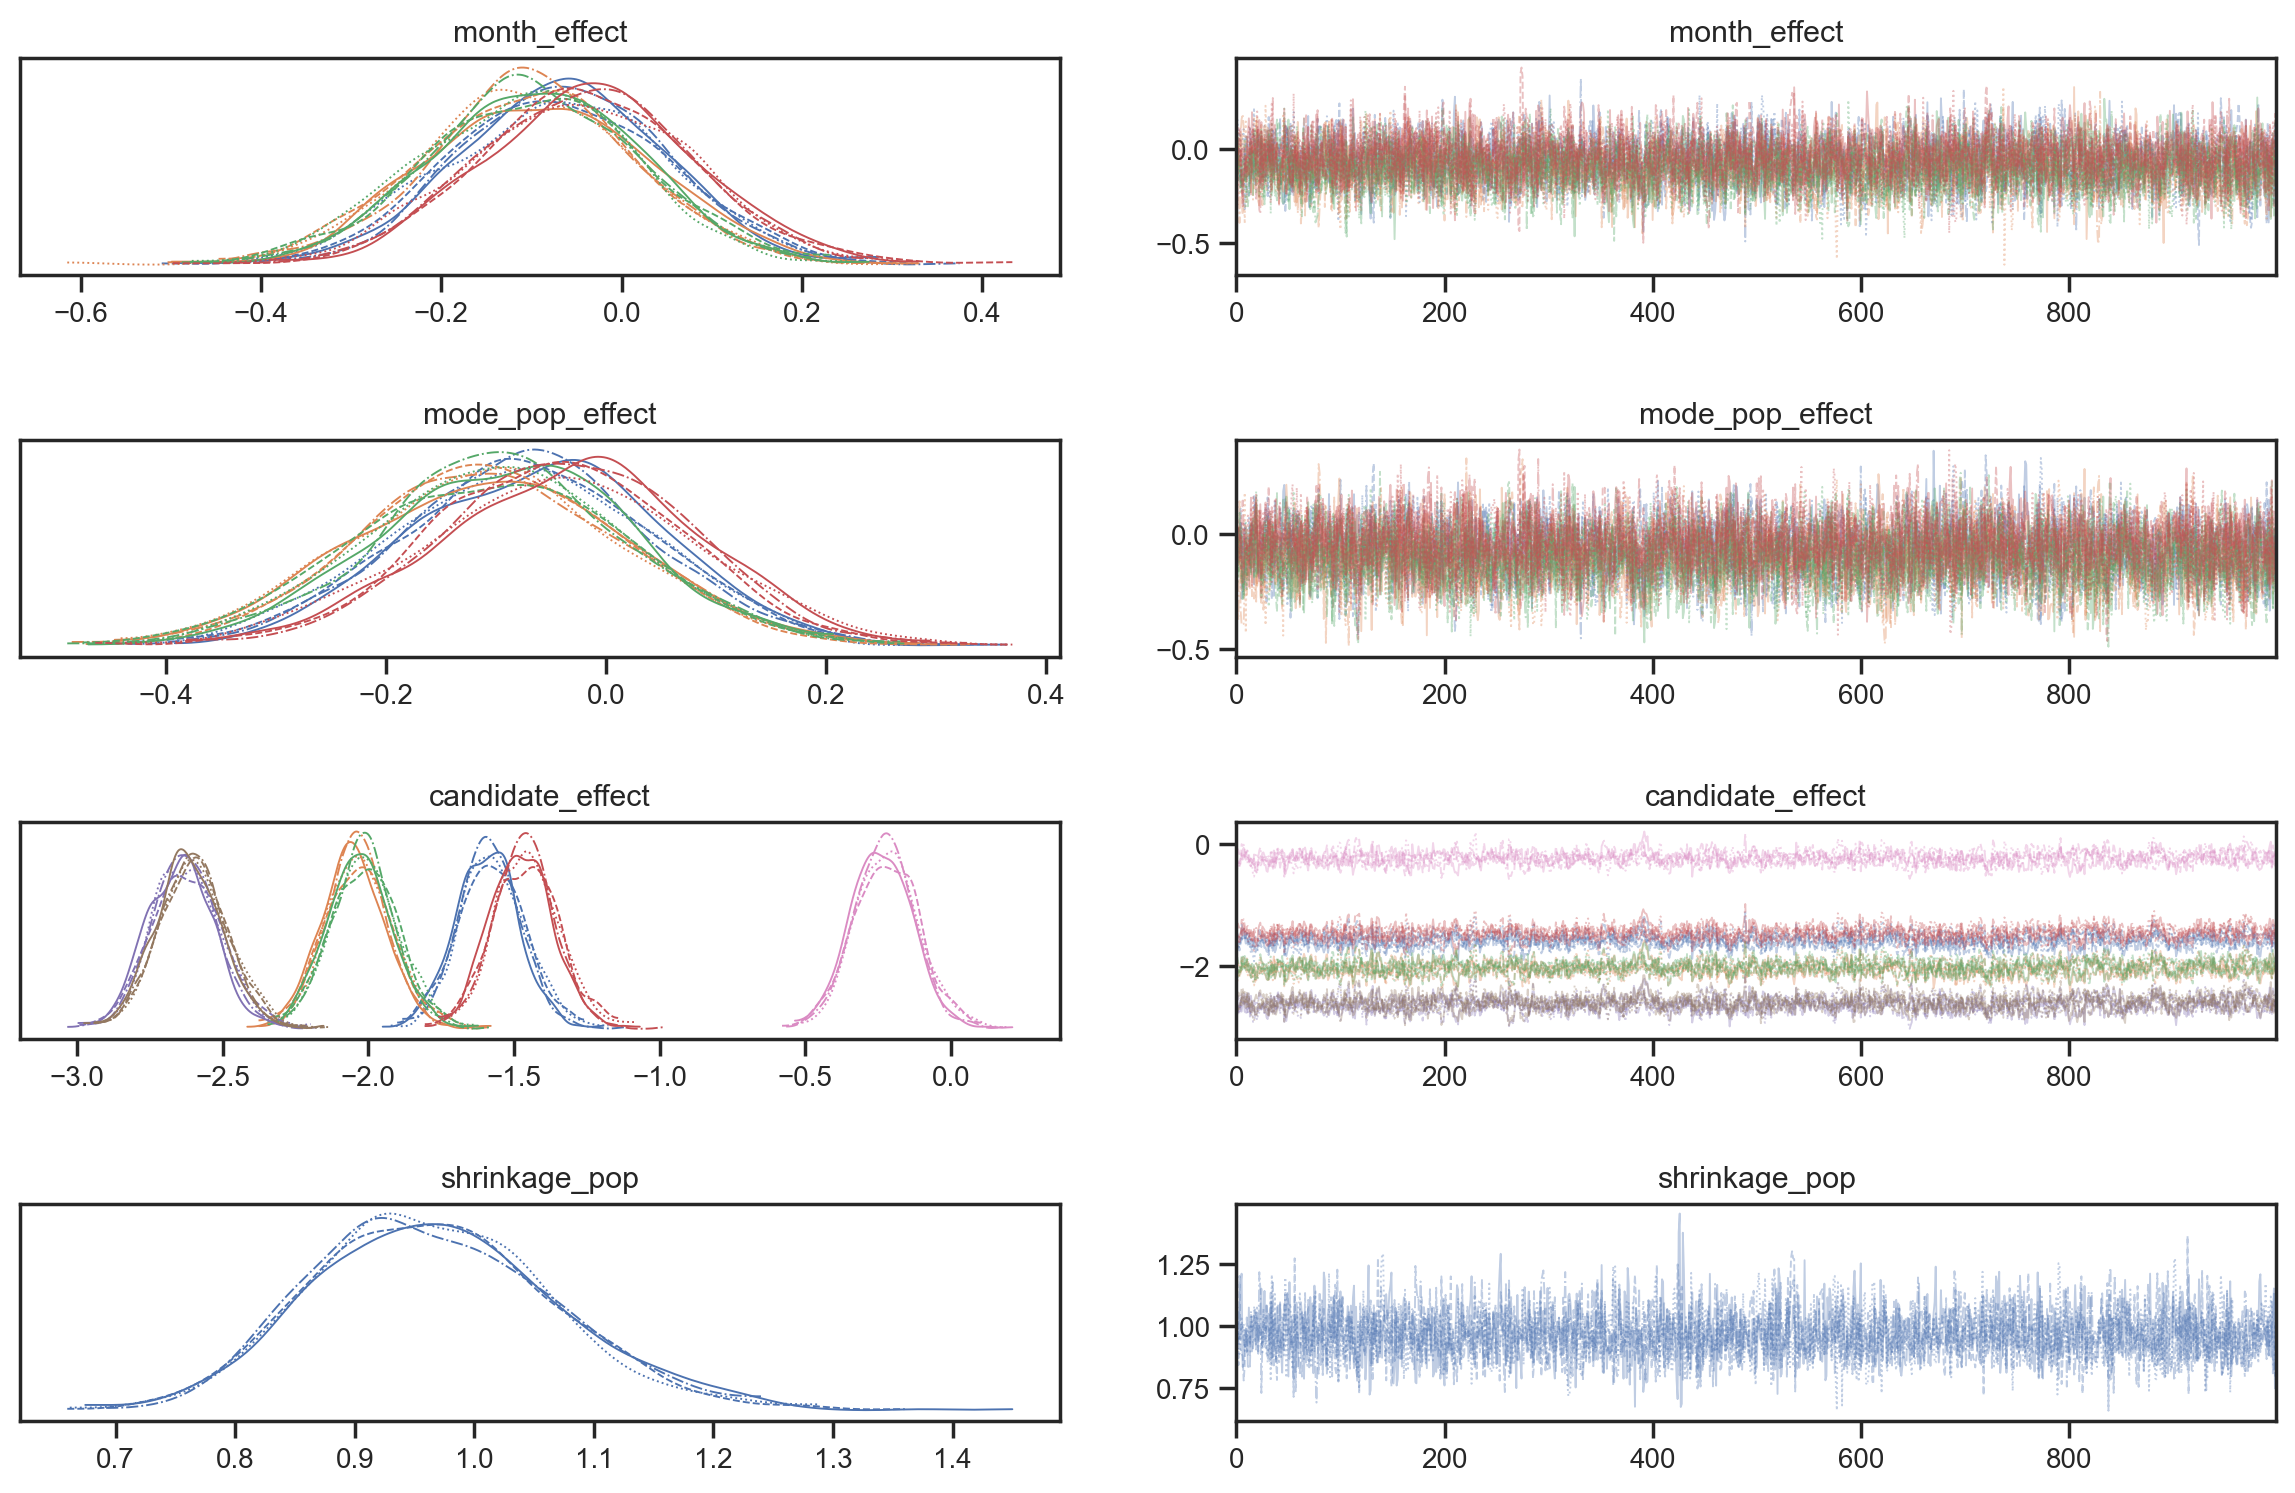

In [21]:
az.plot_trace(idata);
plt.tight_layout()

In [22]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

Sampling: [y_hat]


Output()

In [23]:
cand_preds = {}

for c in idata.posterior.coords["candidate"]:
    post = idata.posterior.sel(candidate=c)
    post_pop = expit(post["month_effect"] +
                     post["mode_pop_effect"] +
                     post["candidate_effect"]).stack(sample=("chain", "draw"))
    cand_preds[str(c.values)] = post_pop.mean(axis=(0, 1))

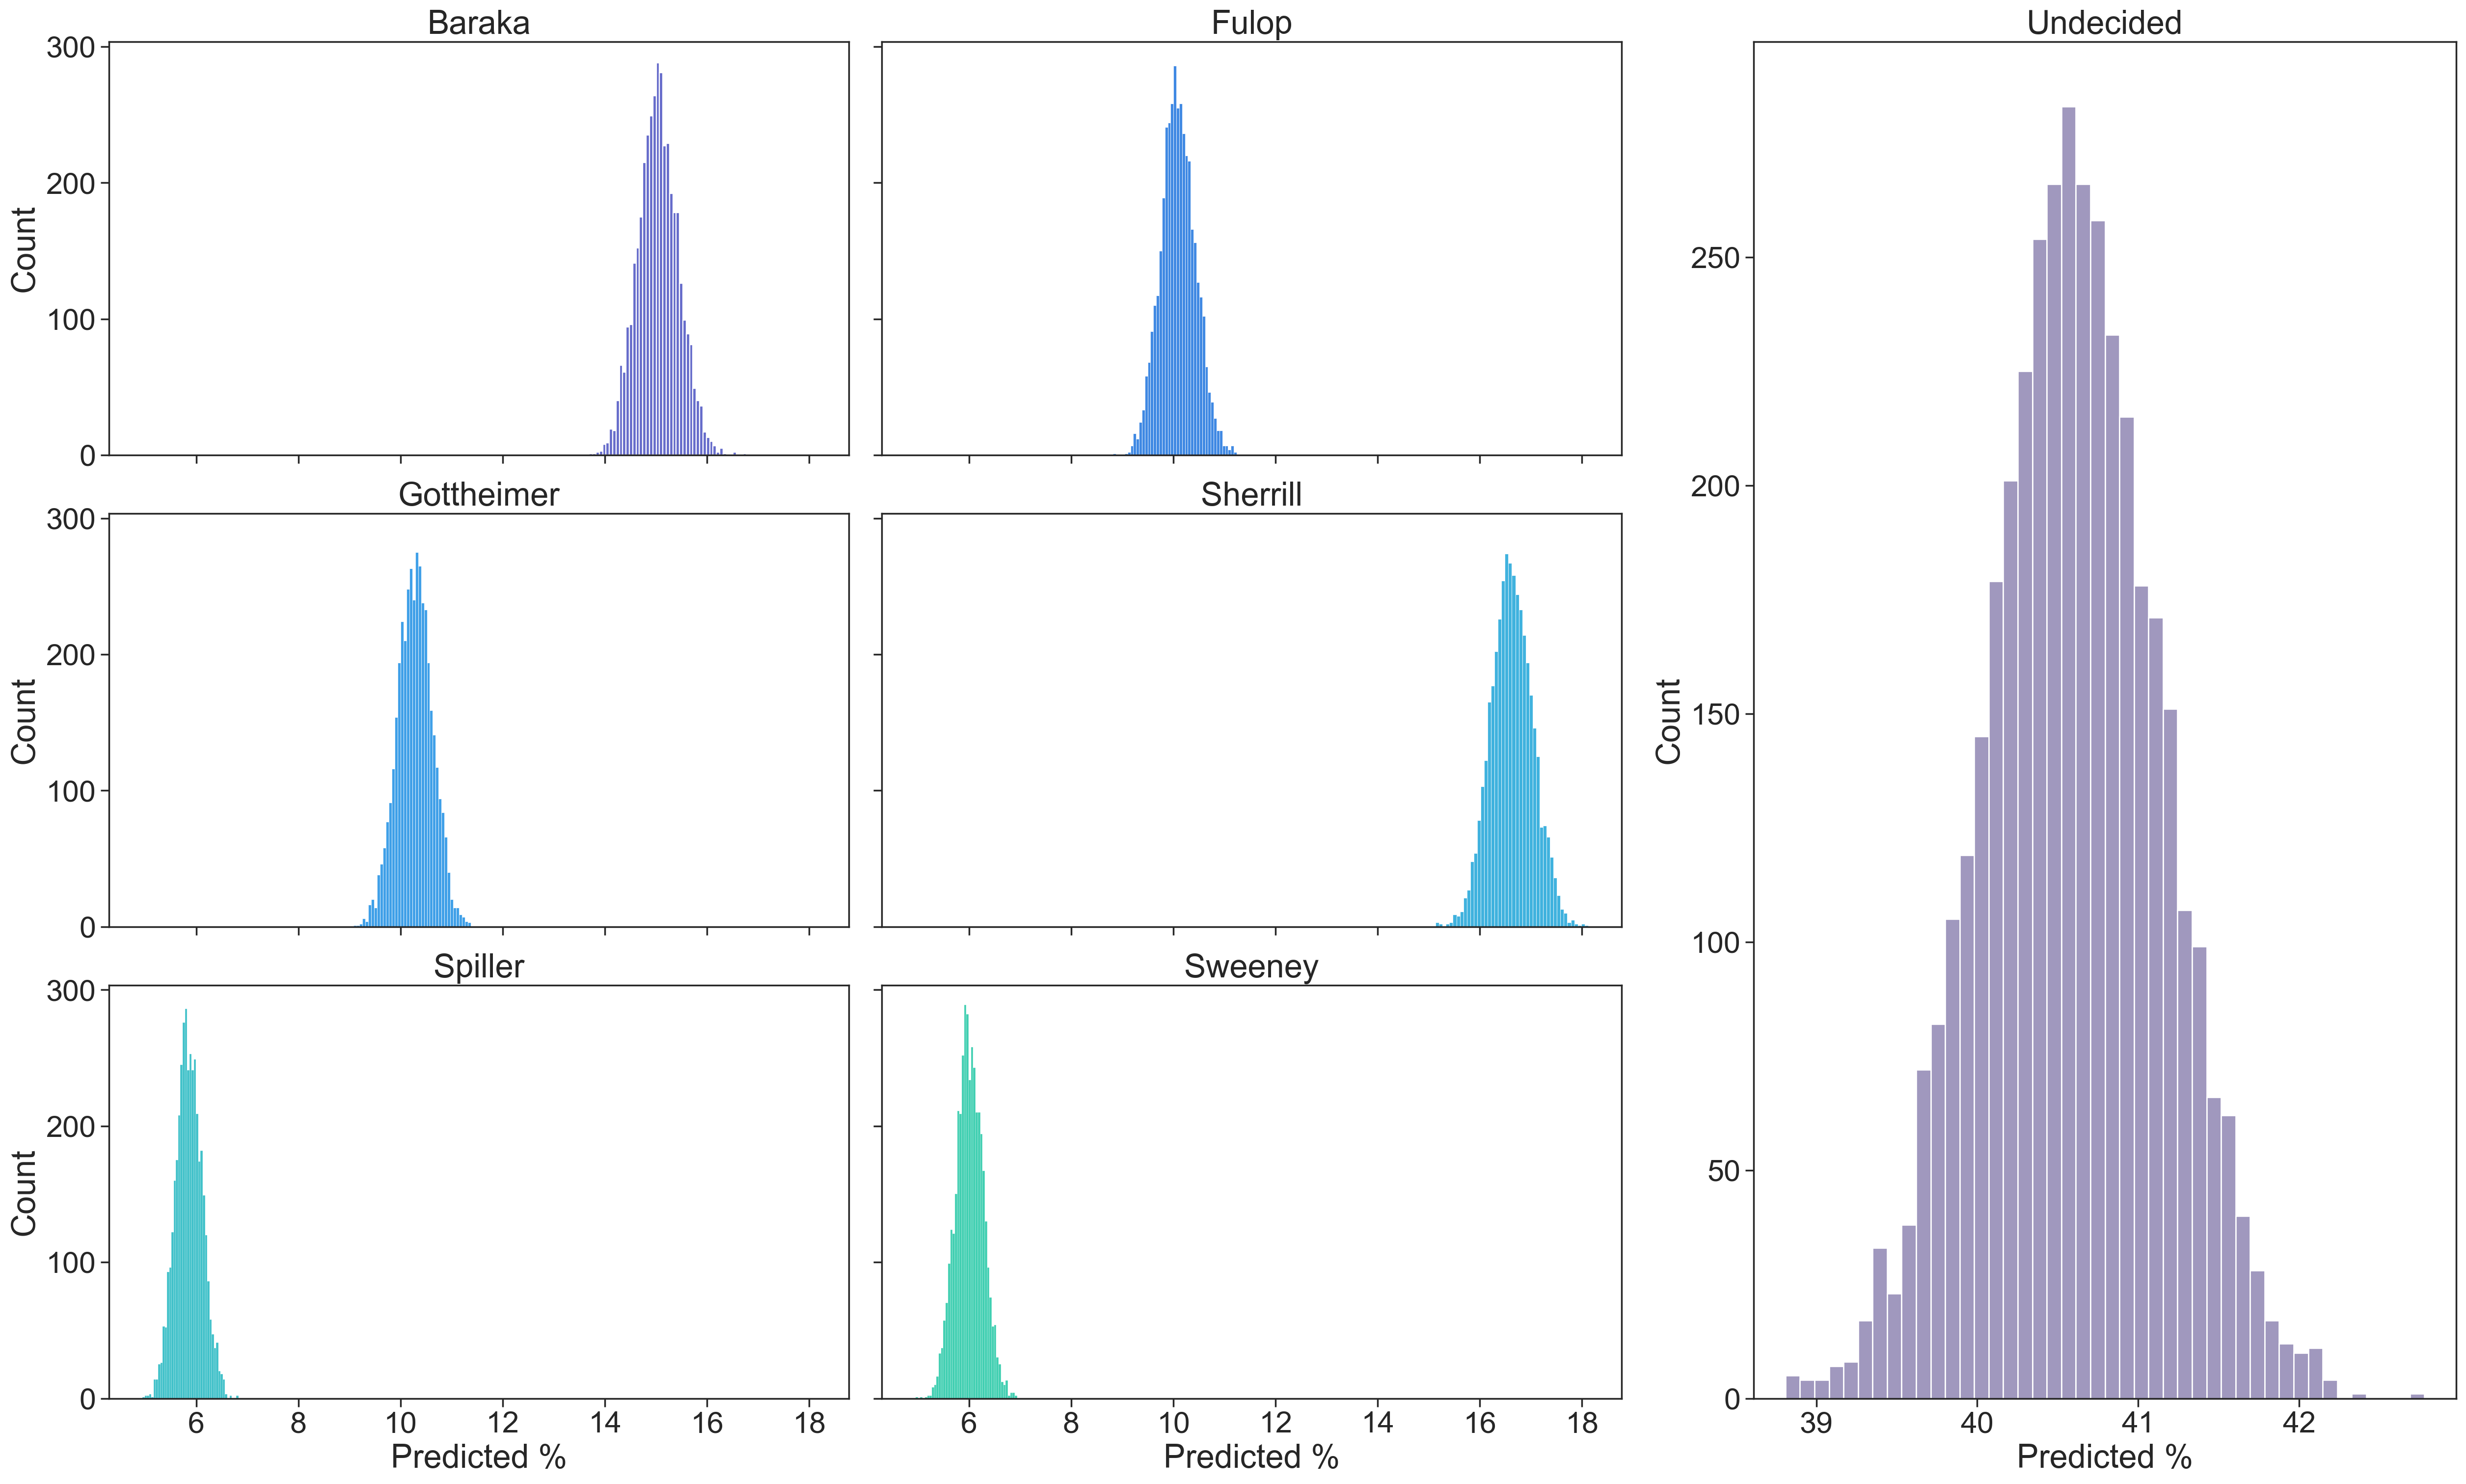

In [24]:
fig = plt.figure(constrained_layout=True)

subfigs = fig.subfigures(1, 2, width_ratios=[2, 1])

axs = subfigs[0].subplots(3, 2, sharex=True, sharey=True)
colors = ["#323ab9", "#0062da", "#0080e1", "#0098d3", "#00adb7", "#00c097"]

for ((cand, ax), color) in zip(zip(cand_preds, axs.ravel()), colors):
    sns.histplot(x=cand_preds[cand] * 100, ax=ax, color=color)
    ax.set_title(cand)
    ax.set_xlabel("Predicted %")

ax = subfigs[1].subplots(1, 1)
sns.histplot(x=cand_preds["Undecided"] * 100, color="#8076a9", ax=ax)
ax.set_title("Undecided")
ax.set_xlabel("Predicted %")

plt.show()

In [25]:
rows = []
for cand in cand_preds:
    row = {"Candidate" : cand,
           "Pred" : np.mean(cand_preds[cand].values),
           "Lower" : np.quantile(cand_preds[cand], 0.025),
           "Upper" : np.quantile(cand_preds[cand], 0.975)}
    rows.append(row)
np_pred_df = pandas.DataFrame(rows)

In [26]:
np_pred_df.sort_values(by=["Pred"], ascending=False)

,Candidate,Pred,Lower,Upper
6,Undecided,0.405946,0.395246,0.416598
3,Sherrill,0.166220,0.158356,0.174338
0,Baraka,0.150462,0.142827,0.158450
2,Gottheimer,0.102786,0.095945,0.109322
1,Fulop,0.100911,0.094504,0.107713
5,Sweeney,0.060060,0.054836,0.065382
4,Spiller,0.058556,0.053521,0.063907


# All Polls (Including Partisan)

In [27]:
cand_id, candidates = df["candidate"].factorize(sort=False)

In [28]:
partisan_id, partisans = df["partisan"].factorize(sort=False)

In [29]:
month_id, months = df["end_date"].dt.to_period("M").factorize(sort=False)
months = [str(m) for m in months]

In [30]:
df["mode_pop"] = df.apply(lambda x : " / ".join([x["mode"], x["population"]]), axis=1)
mode_pop_id, mode_pop = df["mode_pop"].factorize(sort=False)

In [31]:
coords = {
    "observation" : df.index,
    "candidate" : candidates,
    "partisan" : partisans,
    "month" : months,
    "mode_pop" : mode_pop
}

In [32]:
with pm.Model(coords=coords) as model:
    partisan_effect = pm.TruncatedNormal("partisan_effect", mu=0.5, upper=1, lower=0, sigma=0.15, dims="partisan")
    month_effect = pm.Normal("month_effect", 0, 0.15, dims="month")
    mode_pop_effect = pm.Normal("mode_pop_effect", 0, 0.15, dims="mode_pop")
    shrinkage_pop = pm.HalfNormal("shrinkage_pop", 0.2)
    cand_effect = pm.Normal("candidate_effect", mu=0, sigma=shrinkage_pop, dims="candidate")

    popularity = pm.math.invlogit(partisan_effect[partisan_id]
                                  + month_effect[month_id]
                                  + mode_pop_effect[mode_pop_id]
                                  + cand_effect[cand_id])

    y_hat = pm.Binomial(
        "y_hat",
        p=popularity,
        n=df["sample_size"],
        observed=df["num_for"],
        dims="observation",
    )

In [33]:
with model:
    idata = pm.sample(extend_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [partisan_effect, month_effect, mode_pop_effect, shrinkage_pop, candidate_effect]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


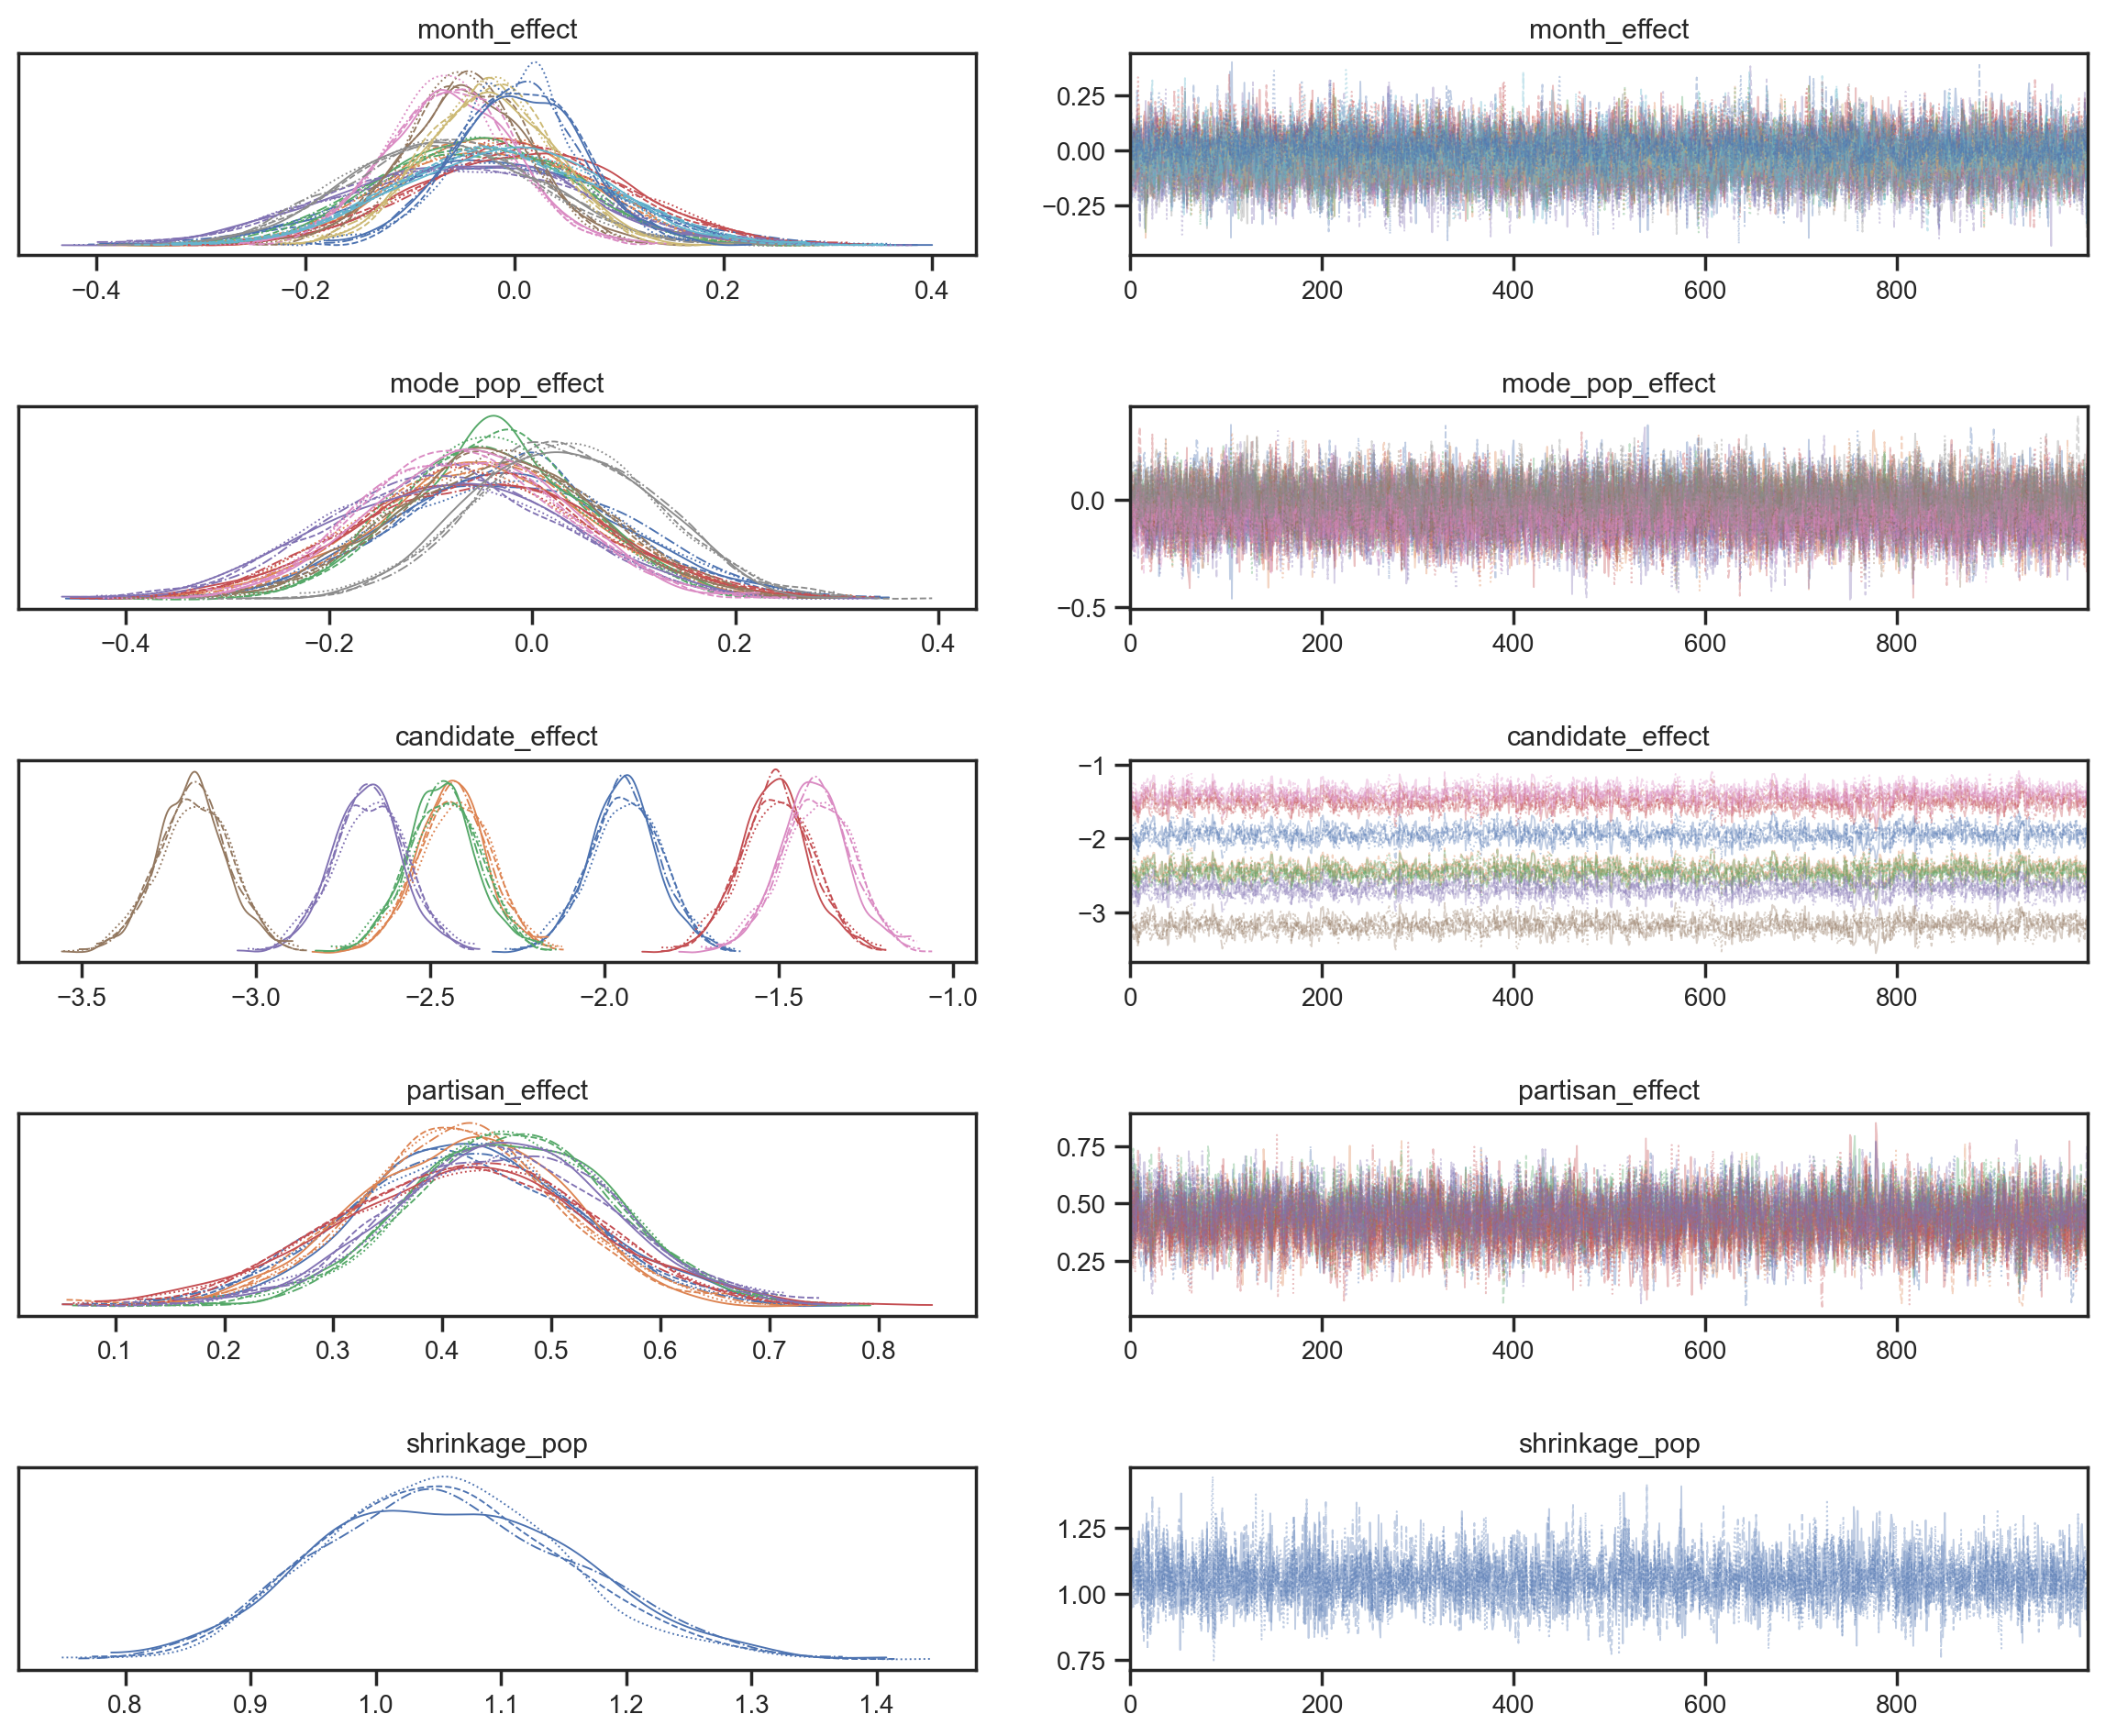

In [34]:
az.plot_trace(idata);
plt.tight_layout()

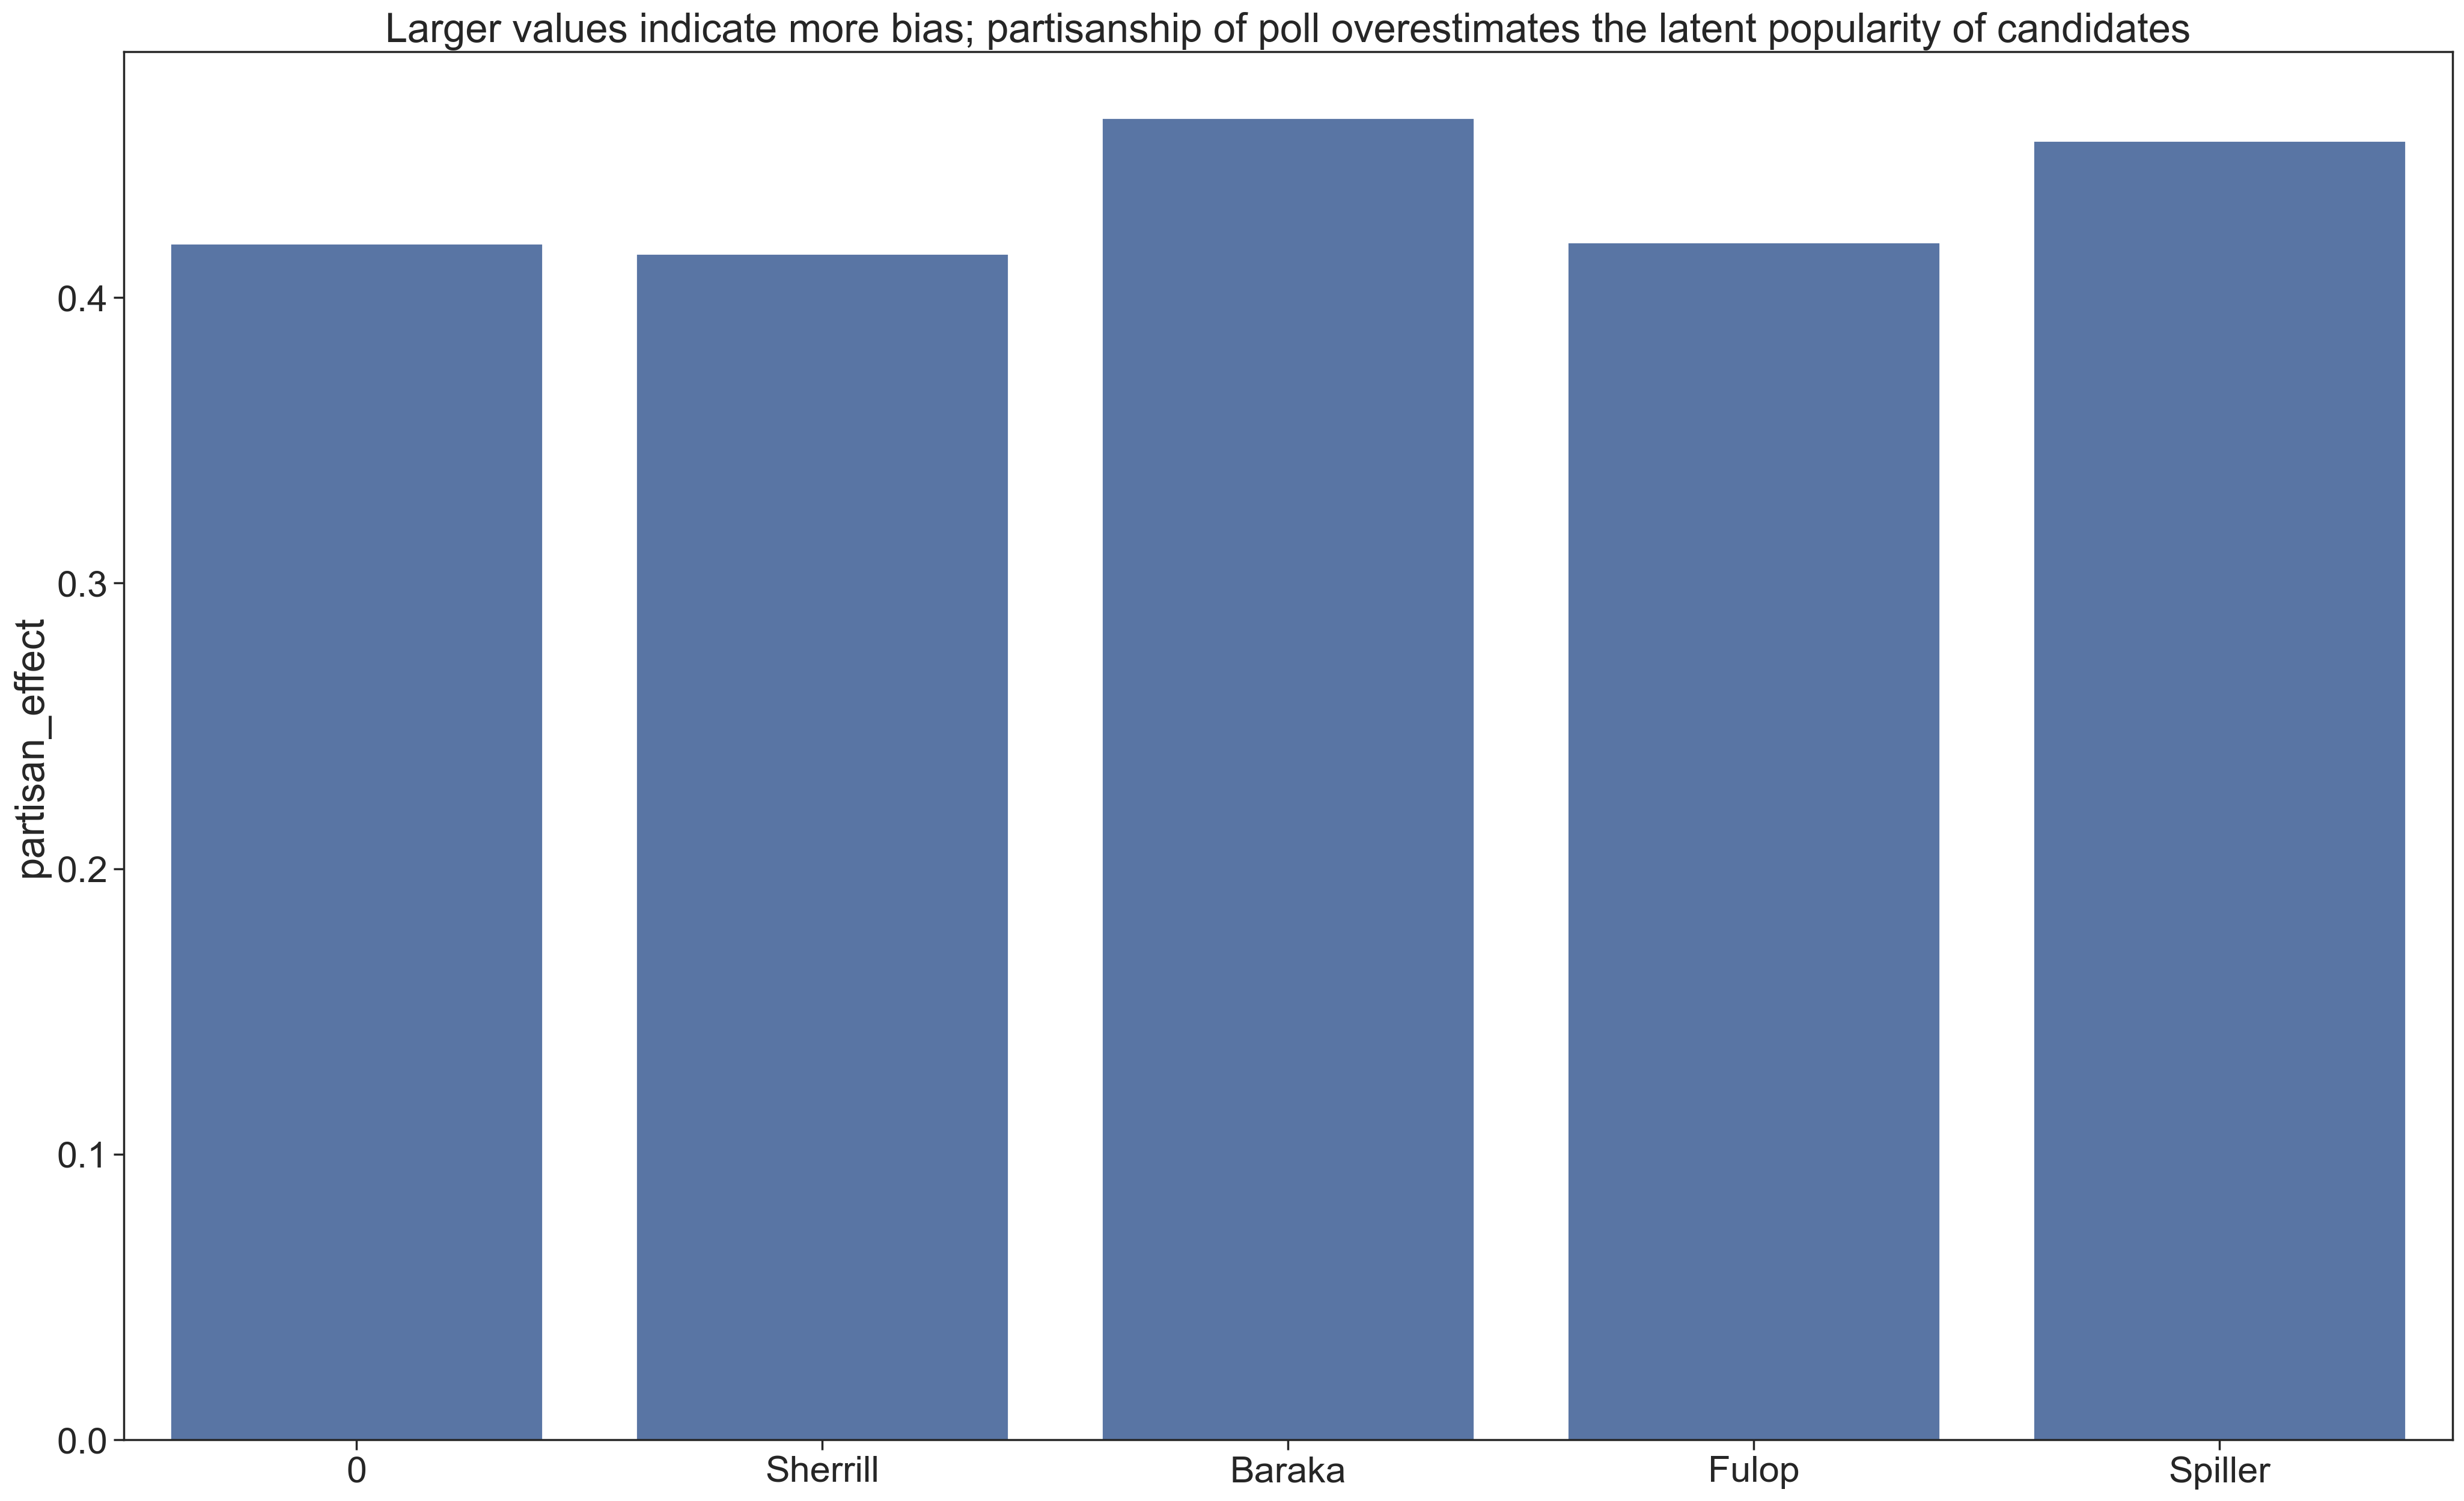

In [35]:
mean_kind_effect = (idata.posterior["partisan_effect"].mean(("chain", "draw")).to_dataframe()).reset_index()
ax = sns.barplot(data=mean_kind_effect, x="partisan", y="partisan_effect")
# ax.axhline(0, color="black", linestyle="--", linewidth=2)
ax.set_title("Larger values indicate more bias; partisanship of poll overestimates the latent popularity of candidates")
ax.set_xlabel(None)
plt.show()

In [36]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

Sampling: [y_hat]


Output()

In [37]:
partisan_cand_preds = {}

for c in idata.posterior.coords["candidate"]:
    post = idata.posterior.sel(candidate=c)
    post_pop = expit(post["partisan_effect"] +
                     post["month_effect"] +
                     post["mode_pop_effect"] +
                     post["candidate_effect"]).stack(sample=("chain", "draw"))
    partisan_cand_preds[str(c.values)] = dict(zip(post["partisan"].values, post_pop.mean(axis=(1, 2)).values))

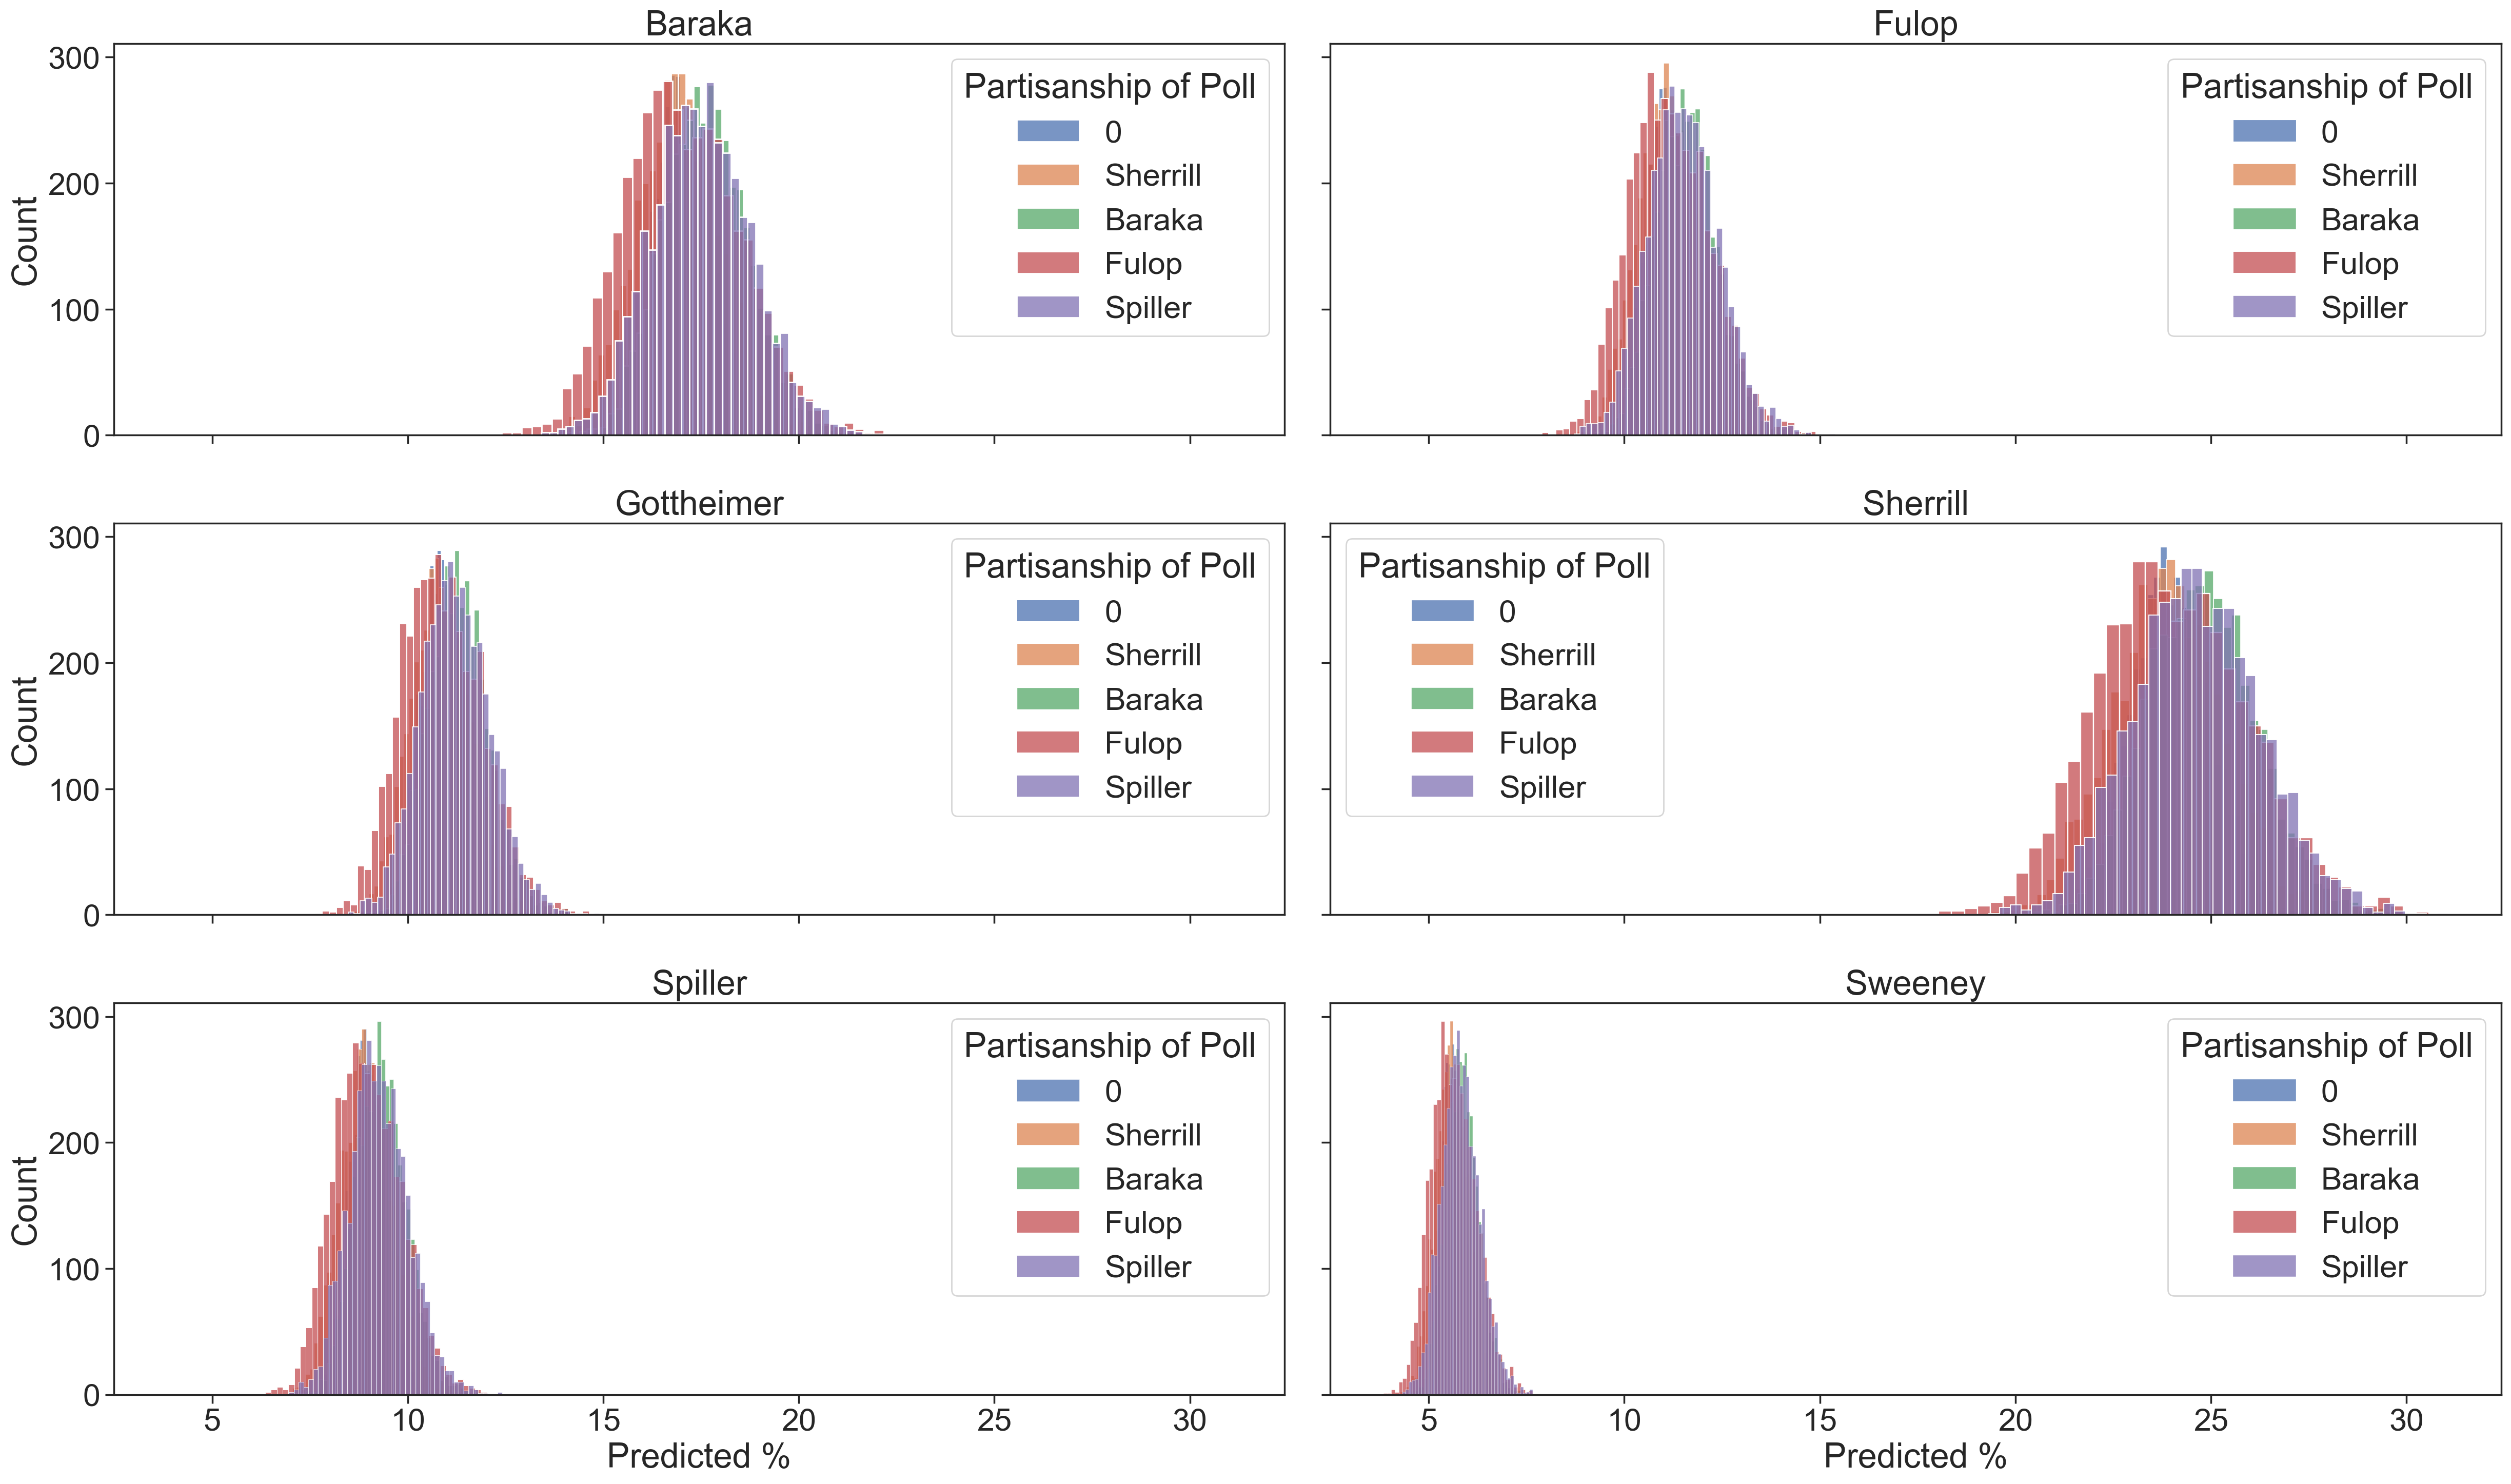

In [38]:
(fig, axs) = plt.subplots(3, 2, sharex=True, sharey=True)
for (cand, ax) in zip(partisan_cand_preds, axs.ravel()):
    for kind in partisan_cand_preds[cand]:
        sns.histplot(x=partisan_cand_preds[cand][kind] * 100, label=kind, ax=ax)
    ax.set_title(cand)
    ax.legend(title="Partisanship of Poll")
    ax.set_xlabel("Predicted %")

plt.tight_layout()

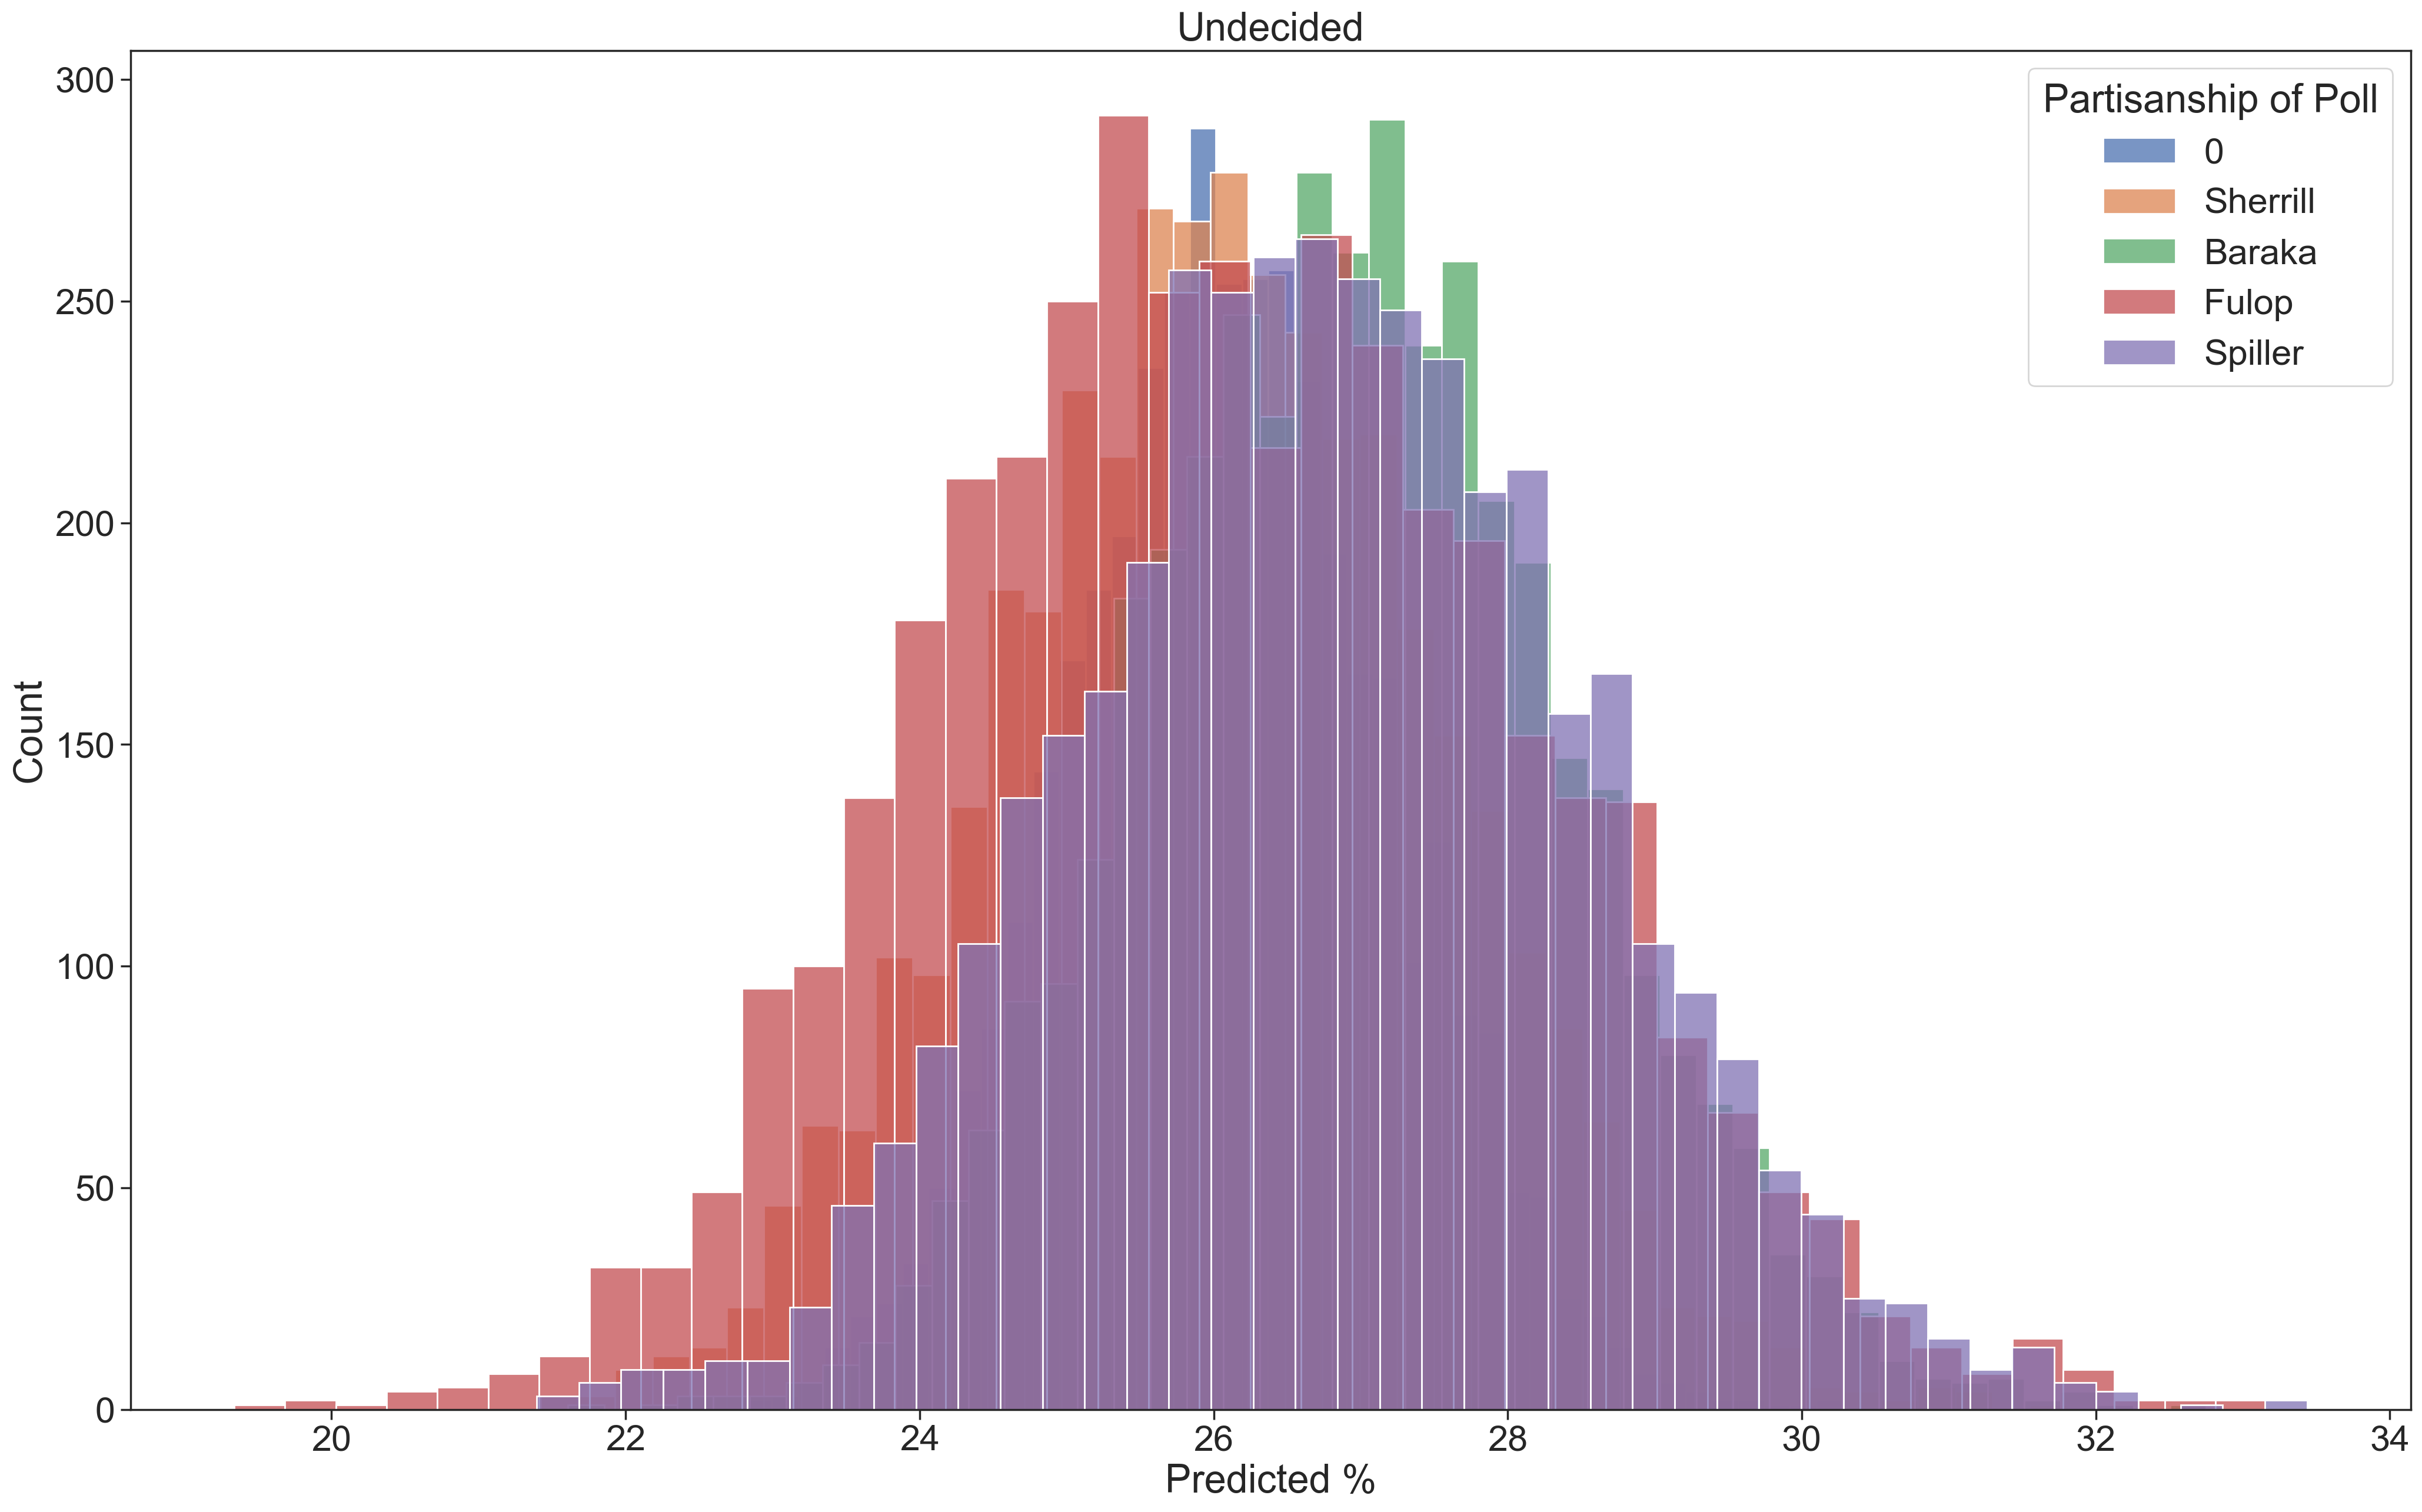

In [39]:
(fig, ax) = plt.subplots(1, 1)
for kind in partisan_cand_preds["Undecided"]:
    sns.histplot(x=partisan_cand_preds["Undecided"][kind] * 100, label=kind, ax=ax)
ax.set_title("Undecided")
ax.legend(title="Partisanship of Poll")
ax.set_xlabel("Predicted %")
plt.show()

In [40]:
partisan_cand_preds = {}

for c in idata.posterior.coords["candidate"]:
    post = idata.posterior.sel(candidate=c)
    post_pop = expit(post["partisan_effect"] +
                     post["month_effect"] +
                     post["mode_pop_effect"] +
                     post["candidate_effect"]).stack(sample=("chain", "draw"))
    partisan_cand_preds[str(c.values)] = post_pop.mean(axis=(0, 1, 2))

In [41]:
rows = []
for cand in partisan_cand_preds:
    row = {"Candidate" : cand,
           "Pred" : np.mean(partisan_cand_preds[cand].values),
           "Lower" : np.quantile(partisan_cand_preds[cand], 0.025),
           "Upper" : np.quantile(partisan_cand_preds[cand], 0.975)}
    rows.append(row)
partisan_pred_df = pandas.DataFrame(rows)

In [42]:
partisan_pred_df.sort_values(by=["Pred"], ascending=False)

,Candidate,Pred,Lower,Upper
6,Undecided,0.264318,0.253438,0.276228
3,Sherrill,0.242602,0.232482,0.254055
0,Baraka,0.172189,0.164357,0.181180
1,Fulop,0.113072,0.107238,0.119765
2,Gottheimer,0.110156,0.104259,0.116937
4,Spiller,0.090928,0.085871,0.096571
5,Sweeney,0.057058,0.053742,0.060897


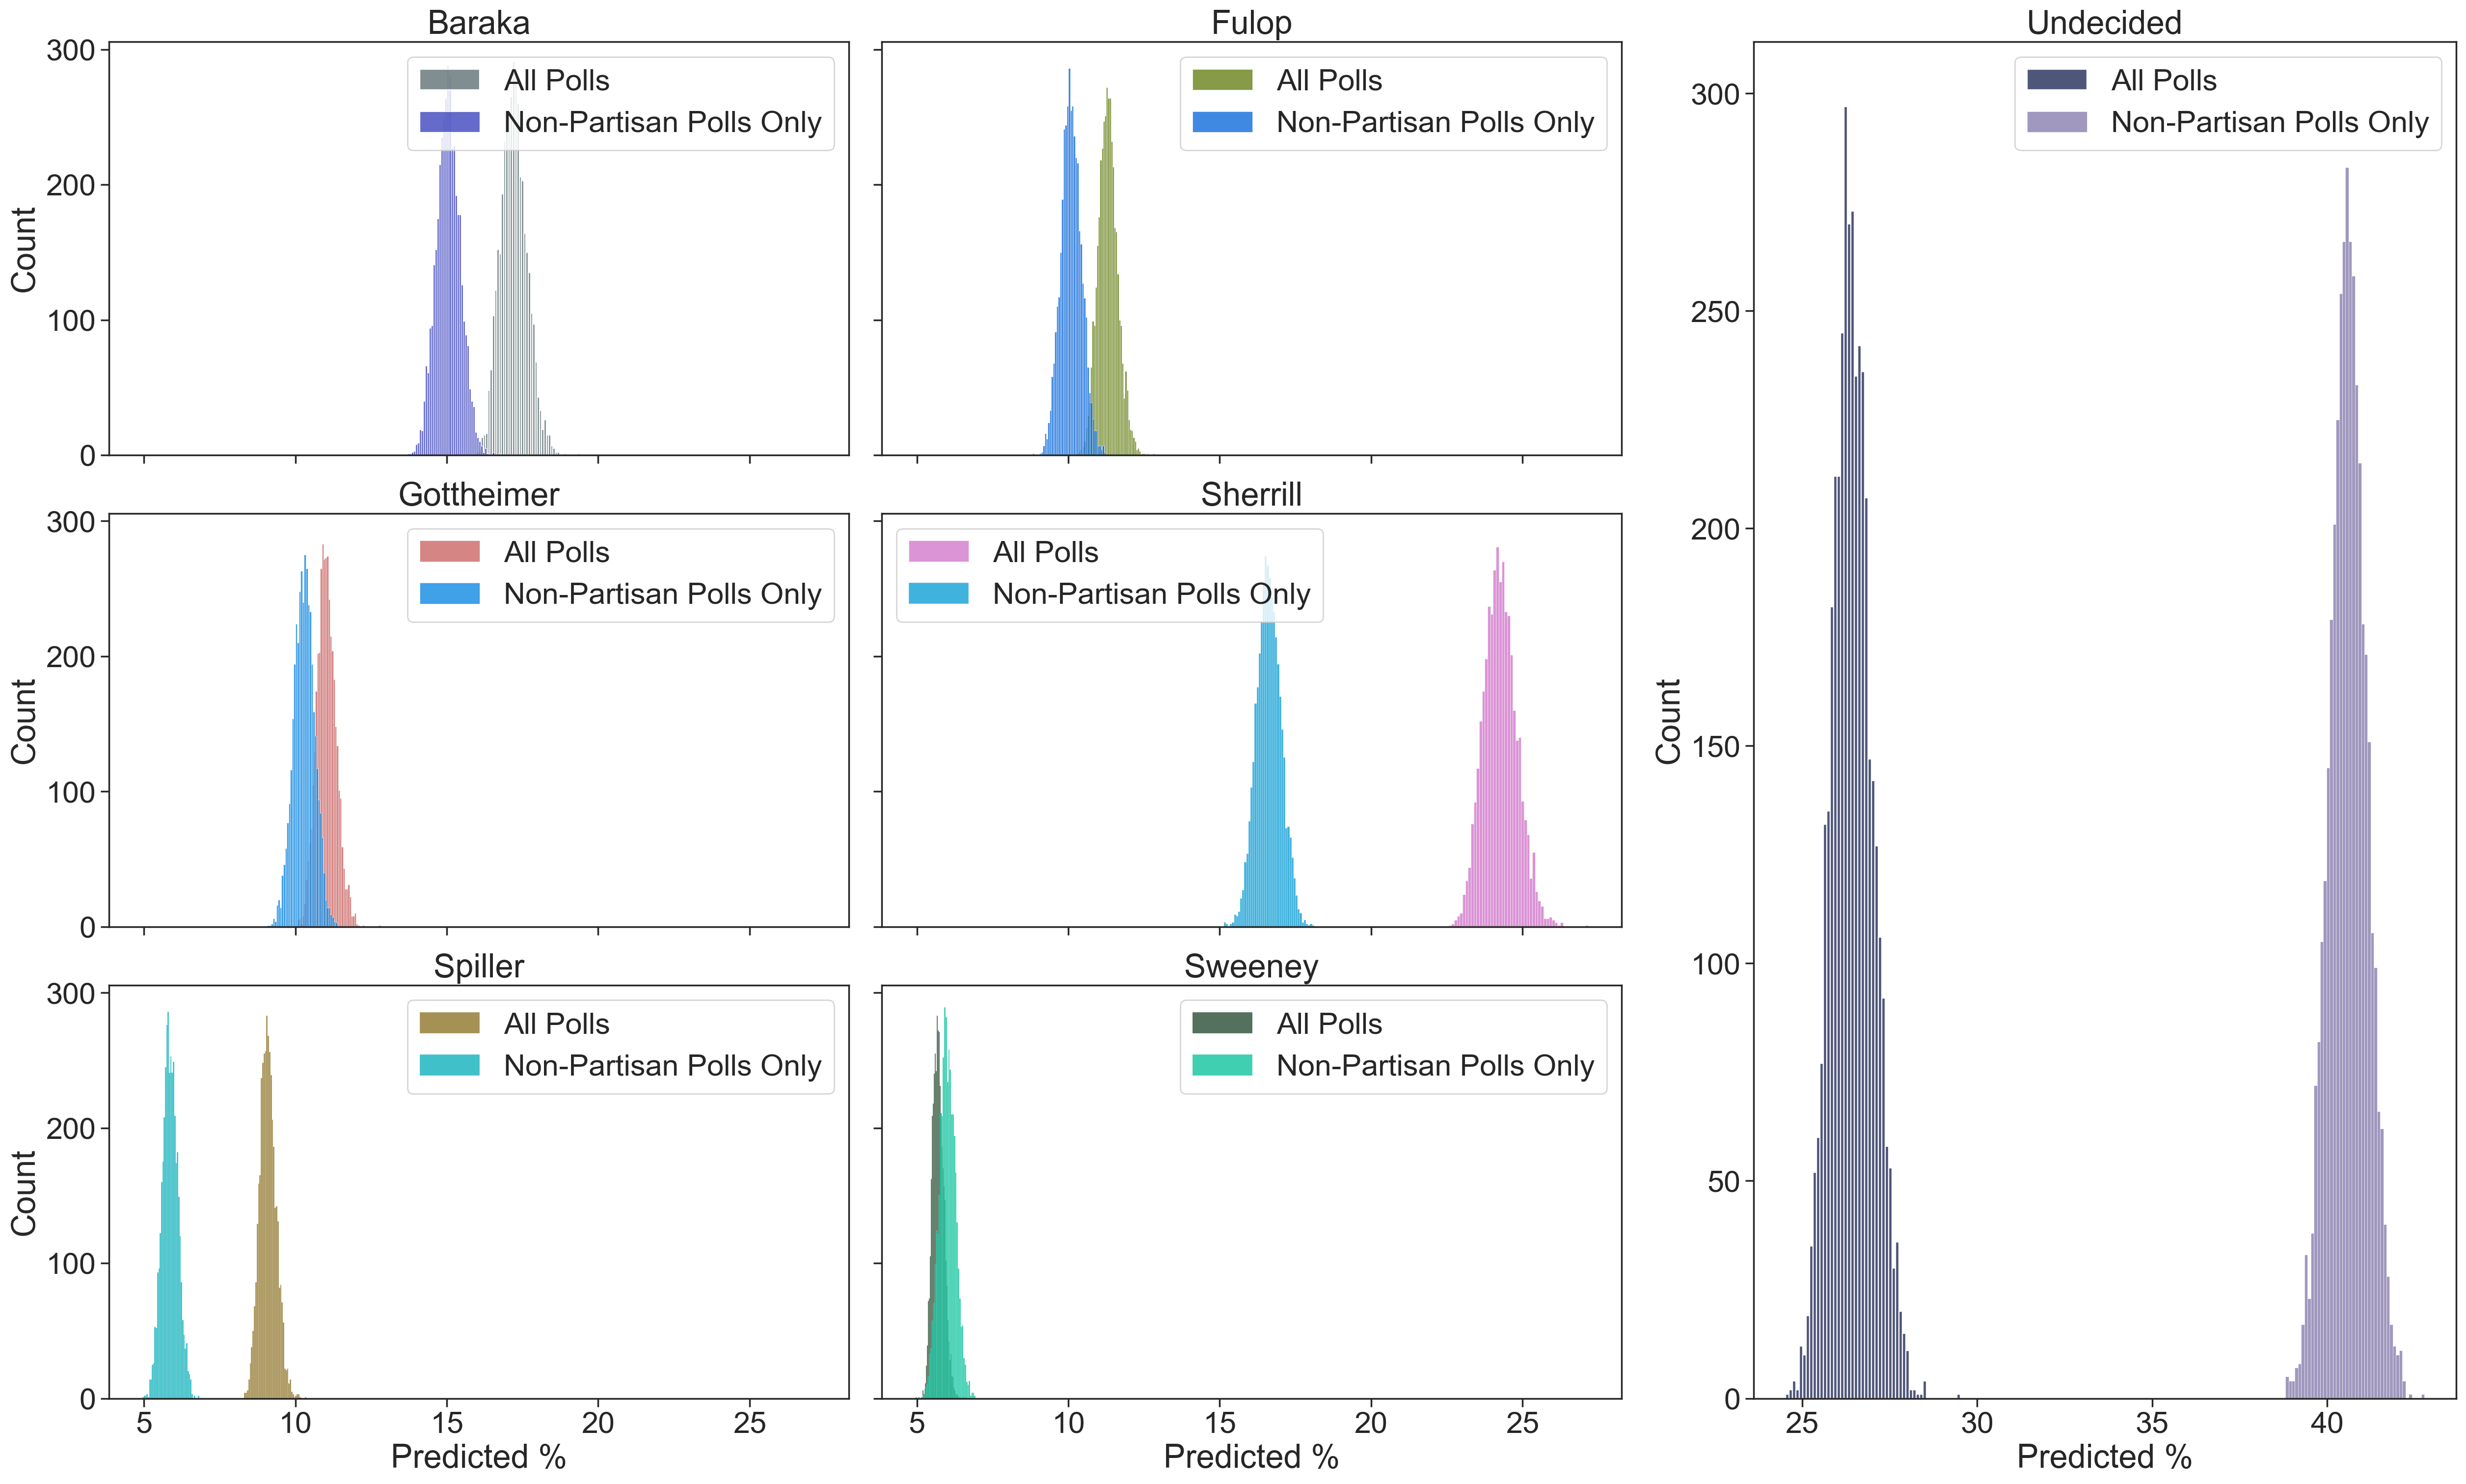

In [43]:
fig = plt.figure(constrained_layout=True)

subfigs = fig.subfigures(1, 2, width_ratios=[2, 1])

axs = subfigs[0].subplots(3, 2, sharex=True, sharey=True)
np_colors = ["#323ab9", "#0062da", "#0080e1", "#0098d3", "#00adb7", "#00c097"]
p_colors = ["#56696C", "#5E790B", "#C85C5B", "#D071C9", "#886D1B", "#1B4127"]

for (i, (cand, ax)) in enumerate(zip(partisan_cand_preds, axs.ravel())):
    sns.histplot(x=partisan_cand_preds[cand] * 100, ax=ax, color=p_colors[i], label="All Polls")
    sns.histplot(x=cand_preds[cand] * 100, ax=ax, color=np_colors[i], label="Non-Partisan Polls Only")
    ax.set_title(cand)
    ax.set_xlabel("Predicted %")
    ax.legend()

ax = subfigs[1].subplots(1, 1)
sns.histplot(x=partisan_cand_preds["Undecided"] * 100, color="#121D4E", ax=ax, label="All Polls")
sns.histplot(x=cand_preds["Undecided"] * 100, color="#8076a9", ax=ax, label="Non-Partisan Polls Only")
ax.set_title("Undecided")
ax.set_xlabel("Predicted %")
ax.legend()

plt.show()

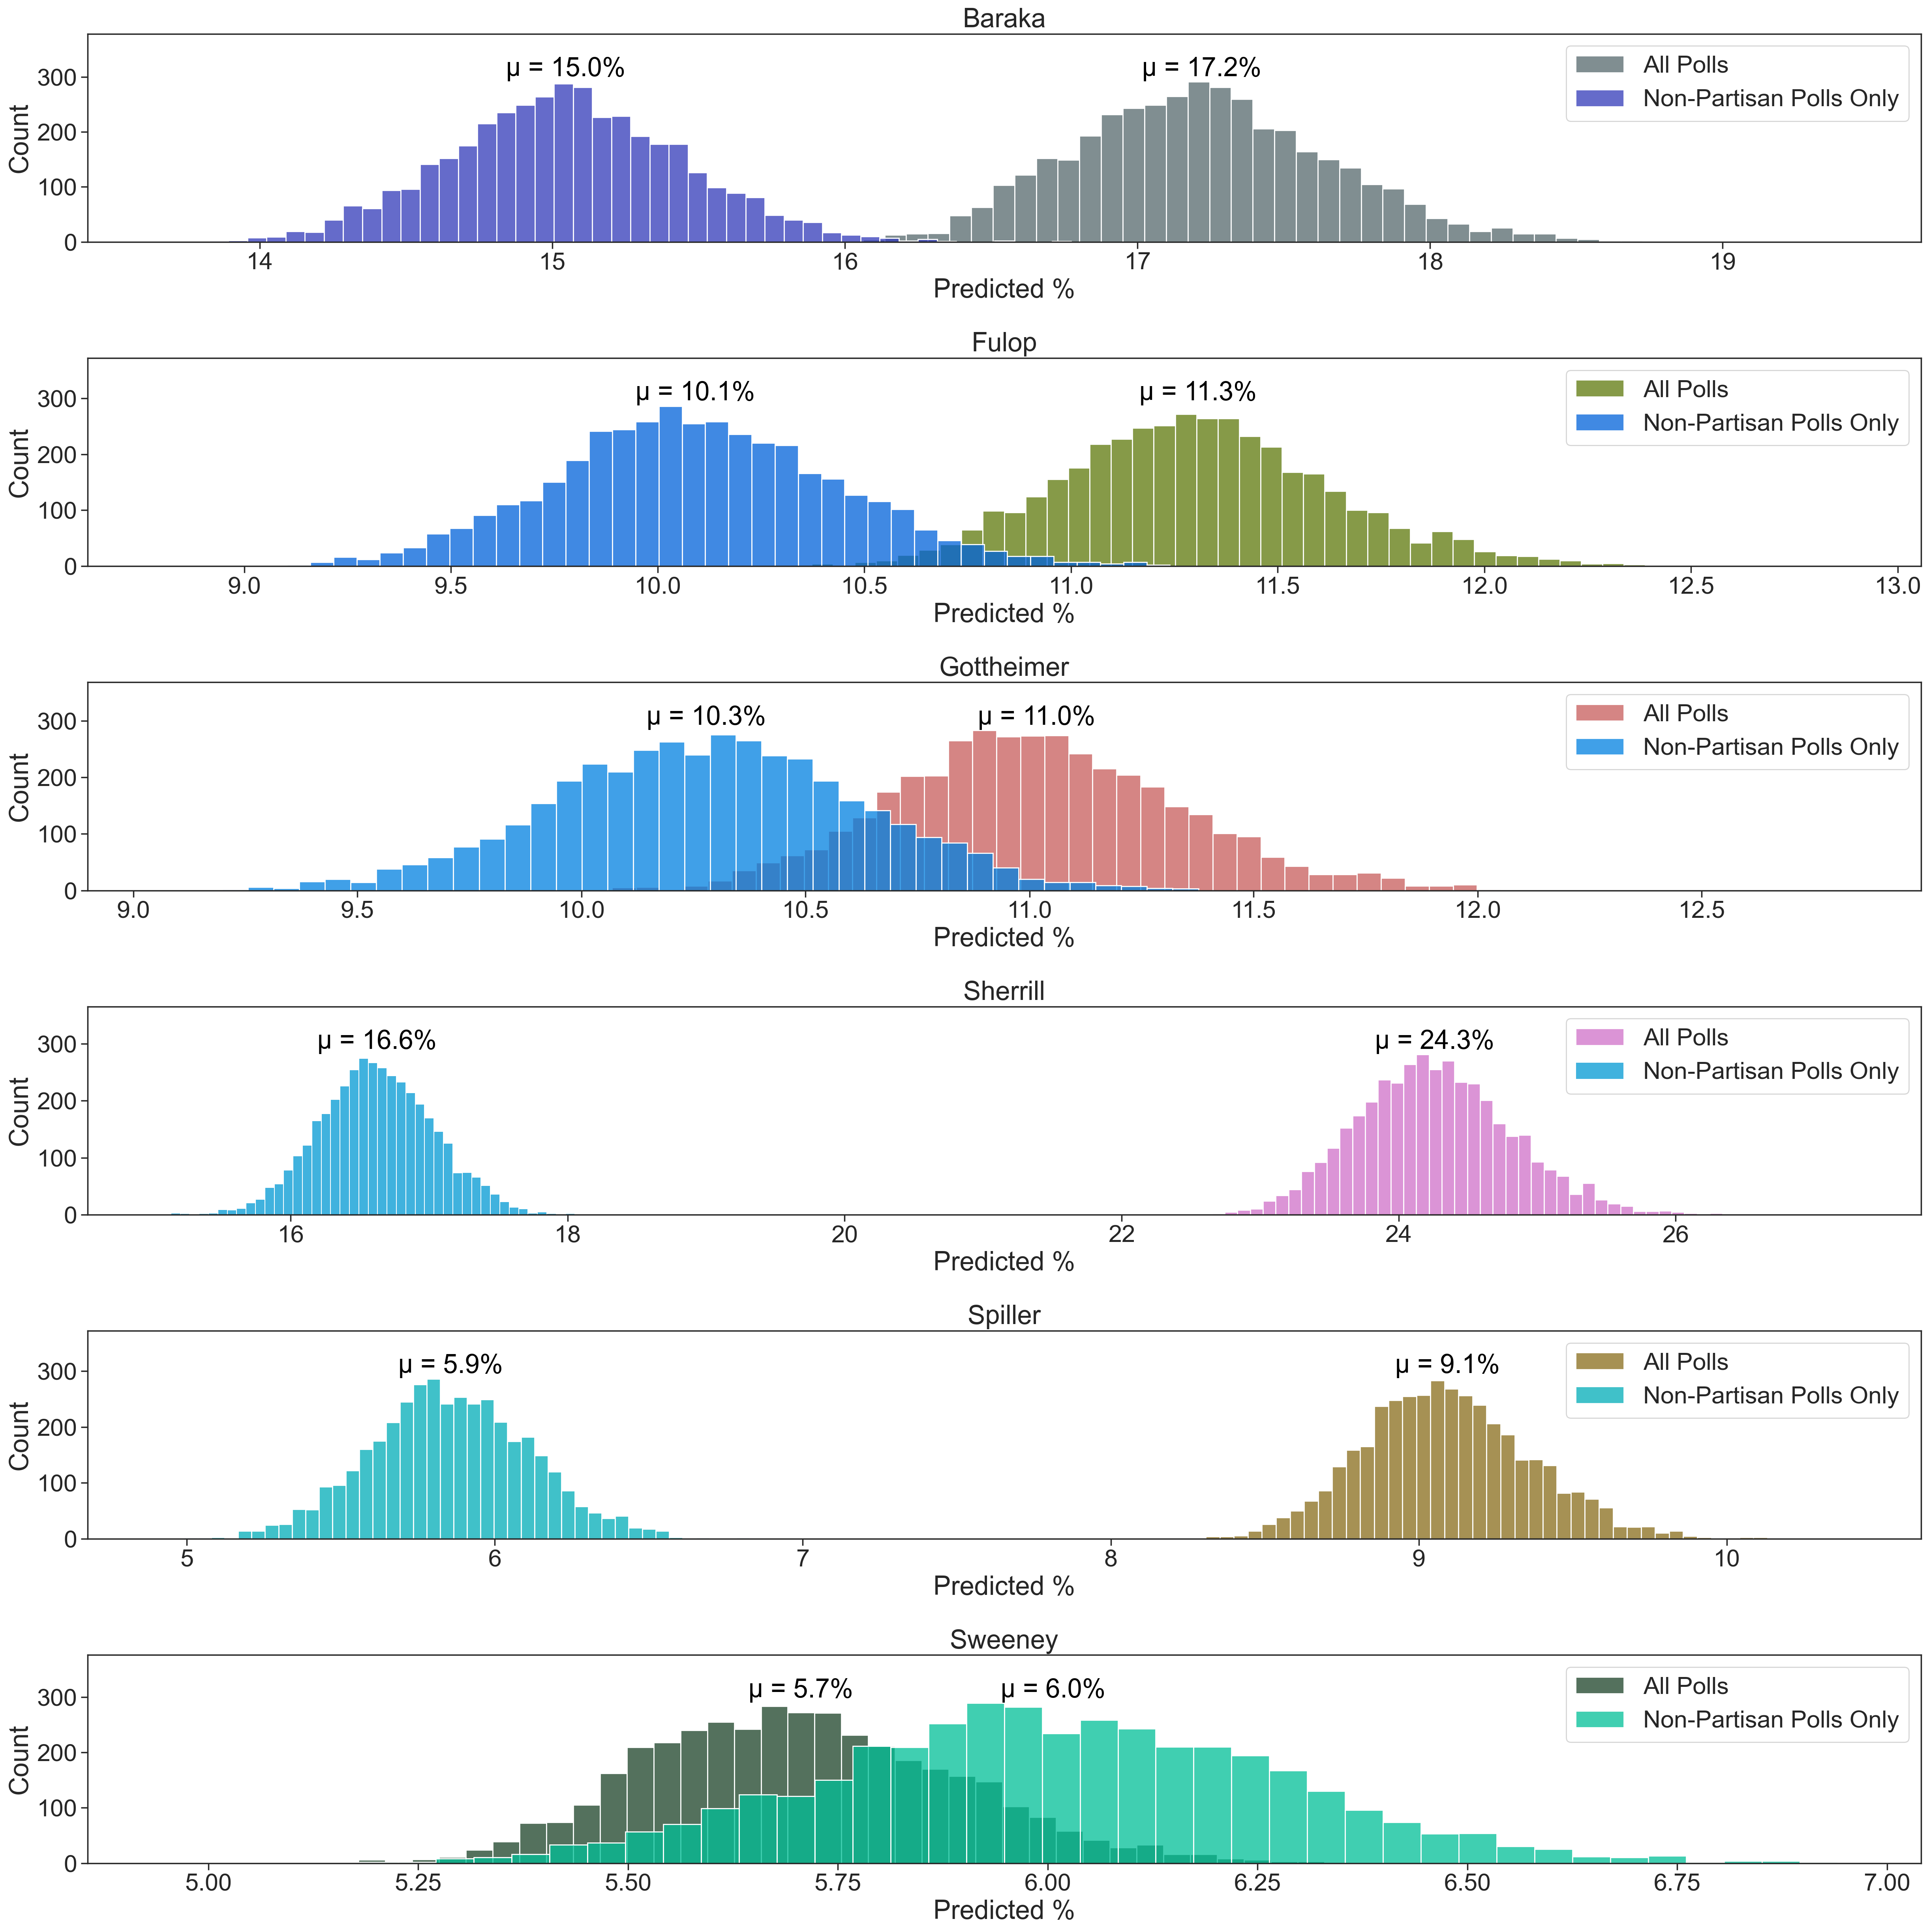

In [44]:
(fig, axs) = plt.subplots(6, 1, sharex=False, sharey=False)
fig.set_size_inches(25, 25)

np_colors = ["#323ab9", "#0062da", "#0080e1", "#0098d3", "#00adb7", "#00c097"]
p_colors = ["#56696C", "#5E790B", "#C85C5B", "#D071C9", "#886D1B", "#1B4127"]

for (i, (cand, ax)) in enumerate(zip(partisan_cand_preds, axs.ravel())):
    sns.histplot(x=partisan_cand_preds[cand] * 100, ax=ax, color=p_colors[i], label="All Polls")
    sns.histplot(x=cand_preds[cand] * 100, ax=ax, color=np_colors[i], label="Non-Partisan Polls Only")
    preds = np_pred_df[np_pred_df["Candidate"] == cand].iloc[0] * 100
    top = max([r.get_height() for r in ax.patches])
    ax.text(preds["Pred"], top + 10, f"μ = {np.round(preds['Pred'], 1)}%", color="black", ha="center")
    preds = partisan_pred_df[partisan_pred_df["Candidate"] == cand].iloc[0] * 100
    ax.text(preds["Pred"], top + 10, f"μ = {np.round(preds['Pred'], 1)}%", color="black", ha="center")
    ax.margins(y=0.3)
    ax.set_title(cand)
    ax.set_xlabel("Predicted %")
    ax.legend()

plt.tight_layout()